# Phase 2 · 7단원 — 비지도 학습

> **정답도 없고 선생님도 없습니다. 알고리즘이 스스로 구조를 찾아냅니다.**

- 원문: <https://aiengineeringfromscratch.com/lesson?path=phases/02-ml-fundamentals/07-unsupervised-learning>
- 예상 시간: 90분 · 선수 지식: Phase 1(노름과 거리, 확률), Phase 2 1~6단원

---

## 📌 출처 표시 규칙

> 📗 **원문** — 커리큘럼에 있는 내용입니다.

> ✨ **추가** — 원문에는 없고, 제가 넣은 비유·예시·실험입니다.

---

## 🎯 이 단원에서 배우는 것

> 📗 **원문** — "Learning Objectives"

1. **K-평균, DBSCAN, GMM**을 밑바닥부터 만들고 셋의 성격을 비교합니다.
2. **실루엣 점수**와 **엘보 방법**으로 군집 품질을 재고 K를 고릅니다.
3. **언제 DBSCAN이 K-평균을 이기는지** 설명하고, 어느 쪽이 이상한 모양·이상치를 다루는지 가려냅니다.
4. 군집화로 **이상 탐지 파이프라인**을 만듭니다.

### 🔑 1~6단원과 결정적으로 다른 점

지금까지는 **전부 정답이 있었습니다.**

| | 1~6단원 (지도 학습) | 7단원 (비지도 학습) |
| --- | --- | --- |
| 데이터 | 입력 + **정답** | **입력만** |
| 목표 | 정답을 맞히기 | **숨은 구조를 찾기** |
| 평가 | 정확도, MSE… | **"정답"이 없어서 직접 못 잼** |
| 예시 | 스팸 분류, 집값 예측 | 고객 분류, 이상 탐지 |

> 📗 원문: "If supervised learning is learning from a textbook with an answer key,
> unsupervised learning is staring at raw data until the patterns reveal themselves."
> (지도 학습이 답지가 있는 교과서로 공부하는 거라면, 비지도 학습은 무늬가 스스로 드러날 때까지 날데이터를 들여다보는 겁니다.)

### 왜 필요한가요? — 라벨은 비쌉니다

> 📗 **원문** — "The Problem"

- 병원에 환자 기록 수백만 건이 있지만, **누가 일일이 병명을 달아 놓지 않았습니다.**
- 쇼핑몰에 세션 로그 수백만 개가 있지만, **고객 유형을 손으로 나눠 놓지 않았습니다.**
- 보안팀에 네트워크 로그가 있지만, **어떤 게 공격인지 표시돼 있지 않습니다.**

> ⚠️ **그런데 함정이 있습니다.** 정답이 없으니 **"맞았다/틀렸다"를 직접 잴 수 없습니다.**
> 그래서 3절에서 **다른 평가 도구**를 따로 배웁니다. 이게 이 단원에서 제일 중요한 부분입니다.

---

## 📖 목차

| # | 내용 | 출처 |
| --- | --- | --- |
| 0 | 군집화란 무엇인가 | 📗 원문 |
| 1 | 🔨 K-평균 밑바닥부터 | 📗 원문 + ✨ 단계별 그림 |
| 2 | K-평균의 약점 두 가지 | 📗 원문 + ✨ 실험 |
| 3 | 🔑 K를 어떻게 고르나 — 엘보와 실루엣 | 📗 원문 + ✨ 직접 구현 |
| 4 | 🔨 DBSCAN 밑바닥부터 | 📗 원문 |
| 5 | 계층적 군집화 — 덴드로그램 | 📗 원문 + ✨ 그림 |
| 6 | 🔨 GMM과 EM — 부드러운 배정 | 📗 원문 |
| 7 | 어떤 걸 언제 쓰나 | 📗 원문 + ✨ 한판 비교 |
| 8 | 군집화로 이상 탐지 | 📗 원문 + ✨ 실험 |
| 9 | 실무 — sklearn | 📗 원문 |
| 10 | 🎒 Ship It — 군집화 선택 가이드 | 📗 원문 `outputs/` |
| 11 | 📝 자가 점검 퀴즈 (5문항) | 📗 원문 `quiz.json` |
| 12 | 용어 사전 · 연습문제 | 📗 원문 |

---

## 🗺️ 이 단원은 이렇게 이어집니다

> ✨ **추가** — 절이 왜 이 순서인지 먼저 짚고 갑니다. 하나가 다음 하나를 불러옵니다.

**0절**에서 "비슷한 것끼리 묶는다"는 목표를 세웁니다. 그런데 **"비슷하다"를 정하는 방식**에 따라
알고리즘이 갈립니다. 그래서 이 단원은 **알고리즘 네 개를 나란히 배우는 게 아니라,
앞 알고리즘의 약점이 다음 알고리즘을 불러오는 순서**로 이어집니다.

- **1절 K-평균** — 가장 단순한 답: "중심 K개를 찍고, 가까운 중심에 붙어라." 먼저 이걸 만듭니다.
- **2절** — 만들어 놓고 보니 약점이 두 개 보입니다. **① 동그란 덩어리만 잘 찾습니다. ② K를 미리 알아야 합니다.**
- **3절** — 일단 ②번(K 고르기)부터 풉니다. 그런데 여기서 **비지도 학습의 진짜 문제**를 만납니다.
  정답이 없으니 **"이 K가 좋은지"를 잴 방법 자체를 새로 만들어야** 합니다 → **엘보**와 **실루엣**.
- **4절** — 이제 ①번 차례입니다. 모양 가정을 아예 없앤 게 **DBSCAN**입니다.
  **덤으로 K도 자동으로 정해지고, 이상치까지 골라냅니다.** 2절의 약점 두 개를 한 번에 해결하죠.
- **5절** — DBSCAN도 완벽하진 않습니다. **밀도가 다르면 무너집니다.**
  "몇 개로 나눌지 미리 안 정하고 **나무를 보고 나중에 자르는**" 방법이 **계층적 군집화**입니다.
- **6절** — 지금까지는 전부 **"이 점은 1번 군집"**이라고 딱 잘라 말했습니다.
  경계에 걸친 점은요? **"70% 1번, 30% 2번"**이라고 말하는 게 **GMM**입니다.
- **7절** — 네 알고리즘을 **같은 데이터 네 종류**에 한꺼번에 붙여서 성격을 비교합니다.
- **8절** — 군집화의 부산물인 **이상 탐지**를 챙깁니다. 세 알고리즘이 각자 다른 방식으로 이상치를 잡습니다.
- **10·11절** — 원문 저장소의 **Ship It 산출물**(선택 가이드)과 **퀴즈 5문항**입니다.
  0~9절에서 배운 걸 **판단 기준 하나로 압축**하고, 스스로 점검합니다.

### 한 줄로 꿰면

> **비슷한 걸 묶자(0) → K-평균으로 묶고(1) → 약점 발견(2) → K 고르는 법 만들고(3)
> → 모양 가정을 버리고(4) → 밀도 문제로 나무를 만들고(5) → 딱 자르지 말고 확률로(6)
> → 한판 비교(7) → 이상 탐지로 써먹기(8)**

In [1]:
# ── 준비물 ──────────────────────────────────────────────────────
import math

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib.patches import Ellipse

np.set_printoptions(precision=3, suppress=True)

available = {f.name for f in fm.fontManager.ttflist}
for cand in ["Apple SD Gothic Neo", "AppleGothic", "NanumGothic",
             "NanumBarunGothicOTF", "Malgun Gothic", "Noto Sans CJK KR"]:
    if cand in available:
        matplotlib.rcParams["font.family"] = ["DejaVu Sans", cand]
        break
matplotlib.rcParams["axes.unicode_minus"] = False
matplotlib.rcParams["figure.dpi"] = 110

색표 = ["tab:blue", "tab:red", "tab:green", "tab:orange", "tab:purple", "tab:brown"]
print("준비 끝!")

준비 끝!


## 0️⃣ 군집화란 무엇인가

> 📗 **원문** — "Clustering: Grouping Similar Things Together"

군집화는 **비슷한 점끼리 같은 그룹에 넣는 일**입니다.
같은 그룹 안의 점끼리는 서로 가깝고, 다른 그룹의 점과는 멀도록요.

> 📗 원문: "The question is always: what does 'similar' mean?"
> (항상 던져야 할 질문은 이겁니다. **'비슷하다'가 뭔데?**)

### 🧸 비유 — 서랍장에 옷 정리하기

옷 무더기를 서랍 여러 칸에 나눠 넣으려고 합니다. 어떻게 나누죠?

- **색깔**로 나눌 수도 있고
- **계절**로 나눌 수도 있고
- **상의/하의**로 나눌 수도 있습니다

**정답이 없습니다.** "비슷하다"를 뭐로 정하느냐에 따라 완전히 다른 정리가 나와요.
그리고 **몇 칸으로 나눌지**도 정해야 합니다.

이 두 가지 질문(**뭐가 비슷한가**, **몇 개로 나누나**)이 이 단원의 전부입니다.

### 📗 네 가지 접근

| 방법 | 나오는 결과 |
| --- | --- |
| **K-평균** | 납작하고 **동그란** 군집 |
| **DBSCAN** | **아무 모양**이나 가능 + 잡음(이상치) 검출 |
| **계층적** | 군집이 겹겹이 든 **나무** |
| **GMM** | **부드러운 배정**(확률), 타원 군집 |

이 순서대로 하나씩 만들어 보겠습니다.

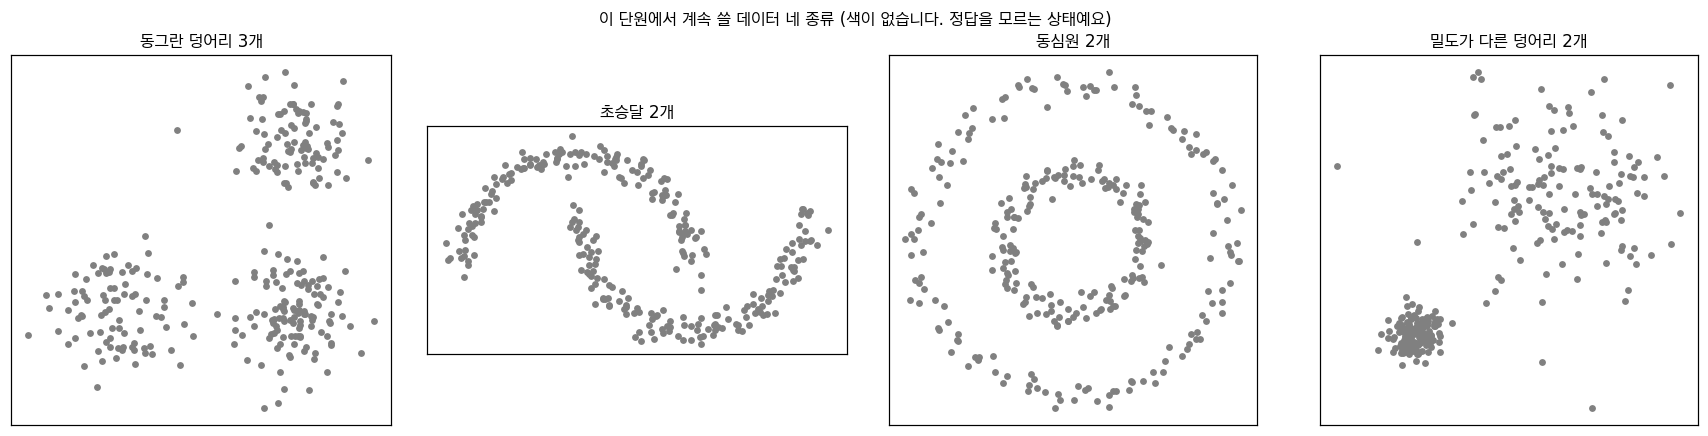

=> 사람 눈에는 '몇 덩어리인지' 바로 보입니다. 알고리즘도 그럴 수 있을까요?
   7절에서 네 알고리즘을 이 네 데이터에 전부 붙여 볼 겁니다.


In [2]:
# ✨ 추가 — 이 단원에서 계속 쓸 데이터 네 종류를 미리 만들어 둡니다
def 덩어리(시드=0, n=300):
    # 동그란 덩어리 3개. K-평균이 좋아하는 모양입니다
    r = np.random.default_rng(시드)
    중심 = np.array([[0.0, 0.0], [5.0, 5.0], [5.0, 0.0]])
    라벨 = r.integers(0, 3, n)
    return 중심[라벨] + r.normal(0, 0.9, size=(n, 2)), 라벨

def 초승달(시드=0, n=300):
    # 길쭉하게 휜 모양. K-평균이 못 하는 모양입니다
    from sklearn.datasets import make_moons
    X, y = make_moons(n_samples=n, noise=0.07, random_state=시드)
    return X * 3.0, y

def 동심원(시드=0, n=300):
    from sklearn.datasets import make_circles
    X, y = make_circles(n_samples=n, noise=0.05, factor=0.45, random_state=시드)
    return X * 4.0, y

def 밀도다름(시드=0, n=300):
    # 한쪽은 빽빽하고 한쪽은 성긴 덩어리. DBSCAN이 애먹는 모양입니다
    r = np.random.default_rng(시드)
    A = r.normal([0.0, 0.0], 0.35, size=(n // 2, 2))
    B = r.normal([4.0, 4.0], 1.6, size=(n // 2, 2))
    return np.vstack([A, B]), np.array([0]*(n//2) + [1]*(n//2))

데이터모음 = [("동그란 덩어리 3개", 덩어리), ("초승달 2개", 초승달),
              ("동심원 2개", 동심원), ("밀도가 다른 덩어리 2개", 밀도다름)]

fig, ax = plt.subplots(1, 4, figsize=(16, 4))
for a_, (이름, fn) in zip(ax, 데이터모음):
    Xd, _ = fn(0, 300)
    a_.scatter(Xd[:, 0], Xd[:, 1], s=12, c="gray")
    a_.set_title(이름, fontsize=11)
    a_.set_aspect("equal"); a_.set_xticks([]); a_.set_yticks([])
plt.suptitle("이 단원에서 계속 쓸 데이터 네 종류 (색이 없습니다. 정답을 모르는 상태예요)", fontsize=11)
plt.tight_layout(); plt.show()

print("=> 사람 눈에는 '몇 덩어리인지' 바로 보입니다. 알고리즘도 그럴 수 있을까요?")
print("   7절에서 네 알고리즘을 이 네 데이터에 전부 붙여 볼 겁니다.")

---

## 1️⃣ 🔨 K-평균 밑바닥부터

> 🔗 **앞 절과 이어서** — 0절에서 "비슷한 것끼리 묶자"는 목표를 세웠습니다.
> 가장 단순한 답부터 시도합니다. **"중심 K개를 찍고, 각 점은 가장 가까운 중심에 붙어라."**
> 이 한 줄이 K-평균의 전부입니다.

> 📗 **원문** — "K-Means: The Workhorse" + "Build It: Step 1"

가장 단순한 발상입니다. **"중심 K개를 찍고, 각 점은 가장 가까운 중심에 붙어라."**

### 📗 로이드 알고리즘 (Lloyd's algorithm)

1. 아무 점 **K개를 중심으로** 고릅니다
2. 각 점을 **가장 가까운 중심**에 배정합니다
3. 각 중심을 **자기한테 붙은 점들의 평균**으로 옮깁니다
4. 배정이 안 바뀔 때까지 **2~3을 반복**합니다

### 🧸 비유 — 반장 뽑고 자리 정하기

교실에 아이들이 흩어져 있습니다. 모둠 3개를 만들려면?

1. 아무나 **3명을 반장**으로 정합니다
2. 나머지는 **가장 가까운 반장** 옆에 가서 섭니다
3. 각 반장이 **자기 모둠의 한가운데**로 이동합니다
4. 자리가 바뀌었으니 **다시 가까운 반장 쪽으로** 갑니다 → 반복

**아무도 안 움직일 때까지** 하면 끝입니다.

### 📗 무엇을 최소화하나 — 관성(inertia)

$$\text{inertia} = \sum_i \|x_i - \mu_{c(i)}\|^2$$

각 점에서 **자기 중심까지 거리의 제곱을 다 더한 값**입니다. 작을수록 뭉쳐 있다는 뜻이죠.

> ⚠️ **중요**: K-평균은 이 값의 **지역 최솟값만 찾습니다.**
> 처음에 어디를 찍었느냐에 따라 **다른 답이 나옵니다.** 1절 끝에서 직접 확인합니다.

In [3]:
# 📗 원문 Step 1 — K-평균 (배정 → 중심 이동 반복)
class K평균:
    def __init__(self, K=3, 최대반복=100, 시드=0, 초기화="랜덤"):
        self.K = K
        self.최대반복 = 최대반복
        self.시드 = 시드
        self.초기화 = 초기화        # "랜덤" 또는 "kmeans++"

    def _첫중심(self, X, rng):
        if self.초기화 == "랜덤":
            return X[rng.choice(len(X), self.K, replace=False)].copy()
        # ✨ K-means++ : 이미 뽑힌 중심에서 먼 점일수록 뽑힐 확률을 높입니다
        중심 = [X[rng.integers(len(X))]]
        for _ in range(self.K - 1):
            거리 = np.min(((X[:, None, :] - np.array(중심)[None]) ** 2).sum(-1), axis=1)
            중심.append(X[rng.choice(len(X), p=거리 / 거리.sum())])
        return np.array(중심)

    def 학습(self, X):
        X = np.asarray(X, dtype=float)
        rng = np.random.default_rng(self.시드)
        self.중심 = self._첫중심(X, rng)
        self.기록 = []                      # 그림용으로 매 단계를 저장합니다

        for 회차 in range(self.최대반복):
            # ① 배정: 각 점 -> 가장 가까운 중심
            거리 = np.sqrt(((X[:, None, :] - self.중심[None]) ** 2).sum(-1))
            배정 = 거리.argmin(axis=1)
            self.기록.append((self.중심.copy(), 배정.copy()))

            # ② 중심 이동: 각 중심 -> 자기 점들의 평균
            새중심 = np.array([X[배정 == k].mean(axis=0) if (배정 == k).any()
                              else self.중심[k] for k in range(self.K)])
            if np.allclose(새중심, self.중심):
                break                        # 아무도 안 움직이면 끝
            self.중심 = 새중심

        self.배정 = 배정
        self.반복횟수 = 회차 + 1
        self.관성 = float(((X - self.중심[배정]) ** 2).sum())
        return self

    def 예측(self, X):
        X = np.asarray(X, dtype=float)
        return np.sqrt(((X[:, None, :] - self.중심[None]) ** 2).sum(-1)).argmin(axis=1)

print("K-평균 준비 완료")

K-평균 준비 완료


In [4]:
# 잘 되는지 확인합니다
X1, 진짜라벨 = 덩어리(0, 300)
km = K평균(K=3, 시드=0).학습(X1)

print(f"반복 {km.반복횟수}번 만에 멈췄습니다.")
print(f"관성(inertia) = {km.관성:.2f}\n")
print("찾아낸 중심")
for k, c in enumerate(km.중심):
    print(f"  군집 {k}: {np.round(c, 3)}  (점 {int((km.배정 == k).sum())}개)")

from sklearn.cluster import KMeans
sk = KMeans(n_clusters=3, n_init=10, random_state=0).fit(X1)
print(f"\nsklearn 관성 = {sk.inertia_:.2f}   (우리 {km.관성:.2f})")
print("=> 값이 비슷하면 같은 답을 찾은 겁니다. (중심 번호 순서는 다를 수 있어요)")

반복 5번 만에 멈췄습니다.
관성(inertia) = 472.98

찾아낸 중심
  군집 0: [-0.093  0.019]  (점 89개)
  군집 1: [4.987 4.906]  (점 95개)
  군집 2: [ 4.975 -0.12 ]  (점 116개)

sklearn 관성 = 472.98   (우리 472.98)
=> 값이 비슷하면 같은 답을 찾은 겁니다. (중심 번호 순서는 다를 수 있어요)


> ✨ **추가** — '배정 → 중심 이동'이 반복되는 걸 단계별로 그려 봅니다. 이걸 보면 알고리즘이 한눈에 들어옵니다.

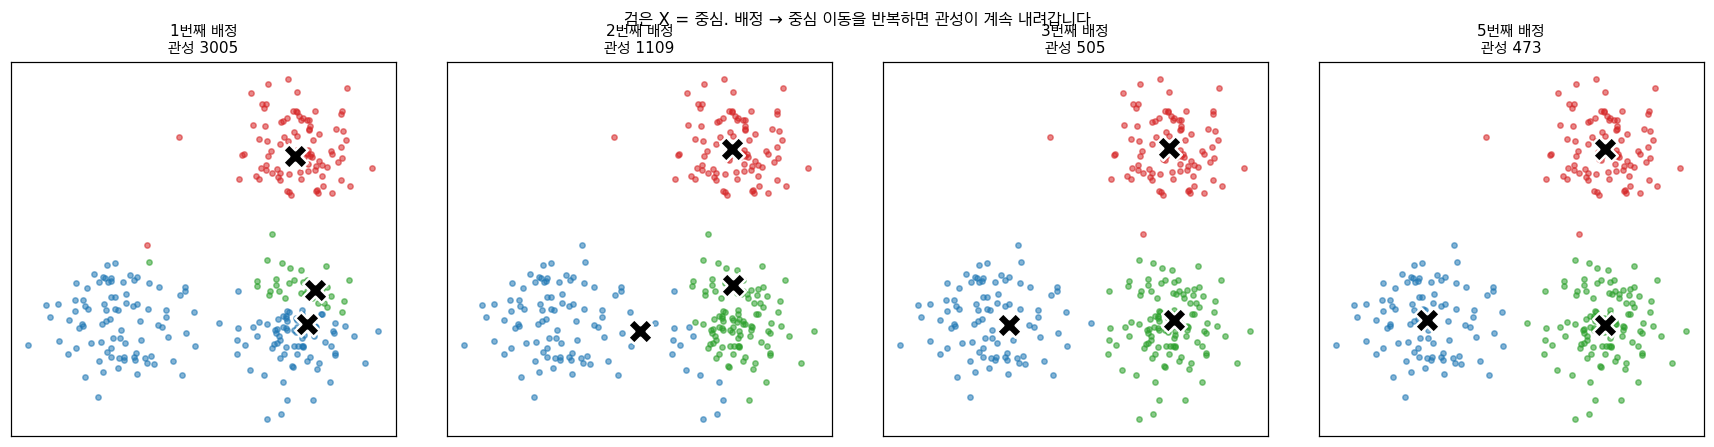

단계별 관성: 3005 -> 1109 -> 505 -> 473 -> 473
=> 한 번도 올라가지 않습니다. 배정도 평균 이동도 둘 다 관성을 줄이는 방향이거든요.
   그래서 K-평균은 '반드시 멈춥니다'. 다만 어디서 멈추는지는 시작점에 달렸습니다.


In [5]:
# ✨ 추가 — K-평균이 수렴하는 과정을 단계별로
보여줄단계 = [0, 1, 2, len(km.기록) - 1]
fig, ax = plt.subplots(1, 4, figsize=(16, 4.1))
for a_, 단계 in zip(ax, 보여줄단계):
    중심, 배정 = km.기록[단계]
    for k in range(3):
        a_.scatter(X1[배정 == k, 0], X1[배정 == k, 1], s=12, c=색표[k], alpha=0.55)
    a_.scatter(중심[:, 0], 중심[:, 1], s=260, c="black", marker="X",
               edgecolors="white", linewidths=1.6, zorder=5)
    관성단계 = float(((X1 - 중심[배정]) ** 2).sum())
    a_.set_title(f"{단계+1}번째 배정\n관성 {관성단계:.0f}", fontsize=10)
    a_.set_aspect("equal"); a_.set_xticks([]); a_.set_yticks([])
plt.suptitle("검은 X = 중심. 배정 → 중심 이동을 반복하면 관성이 계속 내려갑니다", fontsize=11)
plt.tight_layout(); plt.show()

단계별관성 = [float(((X1 - c[a]) ** 2).sum()) for c, a in km.기록]
print("단계별 관성:", " -> ".join(f"{v:.0f}" for v in 단계별관성))
print(f"=> 한 번도 올라가지 않습니다. 배정도 평균 이동도 둘 다 관성을 줄이는 방향이거든요.")
print(f"   그래서 K-평균은 '반드시 멈춥니다'. 다만 어디서 멈추는지는 시작점에 달렸습니다.")

> ✨ **추가** — '시작점에 따라 답이 달라진다'를 확인하고, K-means++가 왜 필요한지 봅니다.

In [6]:
# ✨ 추가 — 시작점을 바꿔 가며 20번 돌려 봅니다
print(f"{'초기화 방식':<14}{'관성 평균':>12}{'관성 최악':>12}{'평균 반복수':>13}{'최악 사례 비율':>15}")
print("-" * 68)
for 방식 in ["랜덤", "kmeans++"]:
    관성들, 반복들 = [], []
    for 시드 in range(20):
        m = K평균(K=3, 시드=시드, 초기화=방식).학습(X1)
        관성들.append(m.관성); 반복들.append(m.반복횟수)
    최선 = min(관성들)
    나쁨 = sum(1 for v in 관성들 if v > 최선 * 1.05)     # 최선보다 5% 이상 나쁜 경우
    print(f"{방식:<13}{np.mean(관성들):>12.1f}{max(관성들):>12.1f}"
          f"{np.mean(반복들):>13.1f}{나쁨/20:>14.0%}")

print("\n=> 랜덤 초기화는 가끔 엉뚱한 곳에서 멈춥니다. 지역 최솟값에 갇힌 거예요.")
print("   K-means++는 '이미 뽑힌 중심에서 먼 점'을 다음 중심으로 뽑아 이걸 줄입니다.")
print("   💡 그래서 sklearn의 기본값이 init='k-means++', n_init=10 입니다.")
print("      여러 번 돌려서 관성이 가장 낮은 걸 고르는 거죠.")

초기화 방식               관성 평균       관성 최악       평균 반복수       최악 사례 비율
--------------------------------------------------------------------
랜덤                  535.0      1713.0          4.8            5%
kmeans++            473.0       473.0          3.0            0%

=> 랜덤 초기화는 가끔 엉뚱한 곳에서 멈춥니다. 지역 최솟값에 갇힌 거예요.
   K-means++는 '이미 뽑힌 중심에서 먼 점'을 다음 중심으로 뽑아 이걸 줄입니다.
   💡 그래서 sklearn의 기본값이 init='k-means++', n_init=10 입니다.
      여러 번 돌려서 관성이 가장 낮은 걸 고르는 거죠.


---

## 2️⃣ K-평균의 약점 두 가지

> 🔗 **앞 절과 이어서** — 1절에서 K-평균을 만들었습니다. 잘 됐죠.
> 그런데 **잘 된 건 데이터가 동그란 덩어리였기 때문**입니다.
> 여기서 K-평균이 무너지는 지점 두 개를 확인합니다. 이 두 개가 4절 DBSCAN을 부릅니다.

### 📗 약점 ① — 동그란 덩어리만 잘 찾습니다

> 원문: "K-Means assumes clusters are spherical."

K-평균은 **"가장 가까운 중심에 붙어라"**가 전부입니다.
그러면 각 군집의 영역은 **중심들 사이를 직선으로 자른 모양**이 됩니다(보로노이 영역이죠, 6단원에서 봤습니다).

**휘어진 모양은 직선으로 못 자릅니다.**

### 📗 약점 ② — K를 미리 알아야 합니다

> 원문: "requires you to pick K upfront."

그런데 **비지도 학습인데 몇 개로 나눌지 어떻게 알죠?** 그걸 모르니까 군집화를 하는 건데요.

이게 이 단원 최대의 문제입니다. **3절 전체가 이 문제를 다룹니다.**

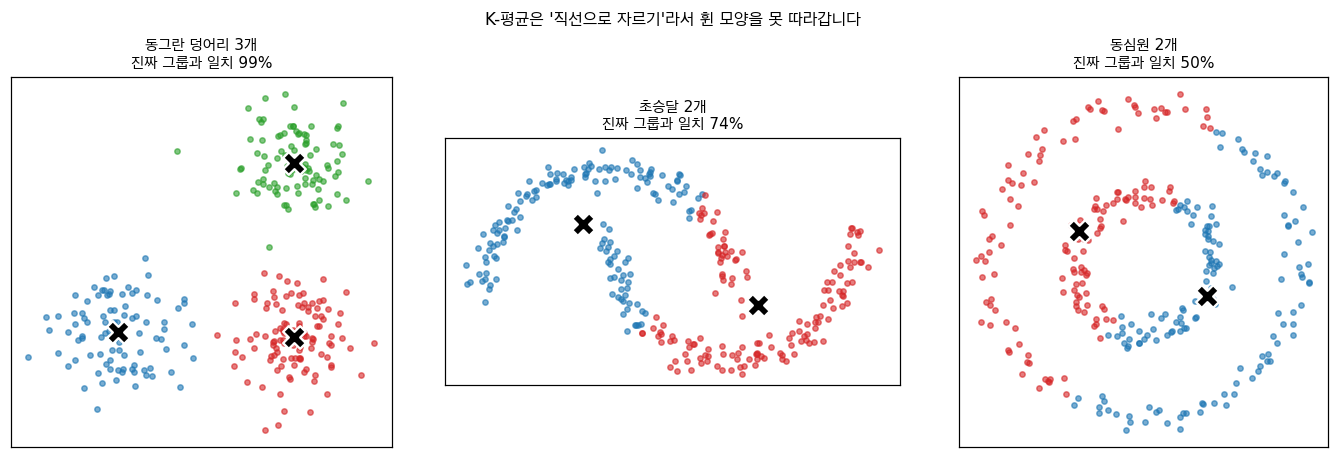

동그란 덩어리 : 거의 완벽합니다.
초승달·동심원 : 완전히 실패합니다. 눈으로는 뻔히 보이는데도요.

=> 원인은 하나입니다. '가장 가까운 중심'이라는 규칙이 곧 '직선으로 자르기'거든요.
   4절 DBSCAN은 중심이라는 개념 자체를 안 씁니다. 그래서 이걸 풉니다.


In [7]:
# ✨ 추가 — 약점 ①: 초승달과 동심원에 K-평균을 붙여 봅니다
fig, ax = plt.subplots(1, 3, figsize=(13, 4.2))
for a_, (이름, fn) in zip(ax, [데이터모음[0], 데이터모음[1], 데이터모음[2]]):
    Xd, 정답 = fn(0, 300)
    K개수 = len(np.unique(정답))
    m = K평균(K=K개수, 시드=0, 초기화="kmeans++").학습(Xd)
    for k in range(K개수):
        a_.scatter(Xd[m.배정 == k, 0], Xd[m.배정 == k, 1], s=12, c=색표[k], alpha=0.6)
    a_.scatter(m.중심[:, 0], m.중심[:, 1], s=220, c="black", marker="X",
               edgecolors="white", linewidths=1.5, zorder=5)
    # '정답과 얼마나 맞았나'를 재려면 군집 번호 순서를 맞춰 줘야 합니다
    from scipy.optimize import linear_sum_assignment
    표 = np.zeros((K개수, K개수))
    for i in range(K개수):
        for j in range(K개수):
            표[i, j] = -np.sum((m.배정 == i) & (정답 == j))
    행, 열 = linear_sum_assignment(표)
    일치 = -표[행, 열].sum() / len(Xd)
    a_.set_title(f"{이름}\n진짜 그룹과 일치 {일치:.0%}", fontsize=10)
    a_.set_aspect("equal"); a_.set_xticks([]); a_.set_yticks([])
plt.suptitle("K-평균은 '직선으로 자르기'라서 휜 모양을 못 따라갑니다", fontsize=11)
plt.tight_layout(); plt.show()

print("동그란 덩어리 : 거의 완벽합니다.")
print("초승달·동심원 : 완전히 실패합니다. 눈으로는 뻔히 보이는데도요.")
print("\n=> 원인은 하나입니다. '가장 가까운 중심'이라는 규칙이 곧 '직선으로 자르기'거든요.")
print("   4절 DBSCAN은 중심이라는 개념 자체를 안 씁니다. 그래서 이걸 풉니다.")

---

## 3️⃣ 🔑 K를 어떻게 고르나 — 엘보와 실루엣

> 📗 **원문** — "Choosing K"
>
> 🔗 **앞 절과 이어서** — 2절의 약점 ②입니다. **몇 개로 나눌지 모르는데 K를 넣으라니.**
> 그런데 이건 단순히 하이퍼파라미터 하나 고르는 문제가 아닙니다.
> **정답이 없는데 어떻게 "좋다"를 재지?** 라는, 비지도 학습의 근본 문제예요.

### 📗 방법 ① — 엘보(팔꿈치) 방법

K를 1, 2, 3, … 으로 늘려 가며 **관성**을 그립니다. 그리고 **꺾이는 지점**을 찾습니다.

### 🧸 왜 꺾이는 곳인가요?

K를 늘리면 관성은 **무조건 줄어듭니다.** K = 점 개수면 관성이 0이에요 (각자 자기가 중심).
그러니까 **"관성이 작다"만 보면 항상 K를 최대로 하라는 답**이 나옵니다. 쓸모없죠.

대신 이렇게 봅니다.

- 진짜 군집 개수보다 **적을 때**는, K를 하나 늘리면 **큰 덩어리가 쪼개지면서 관성이 확 줍니다**
- 진짜 개수를 **넘어서면**, 이미 잘 뭉친 덩어리를 억지로 쪼개는 거라 **찔끔밖에 안 줍니다**

그 **"확 줄다가 찔끔으로 바뀌는 지점"**이 팔꿈치입니다.

### 📗 방법 ② — 실루엣 점수

점 하나하나에 대해 이렇게 잽니다.

- $a$ = **자기 군집 안** 다른 점들까지의 평균 거리 (작을수록 좋음)
- $b$ = **가장 가까운 다른 군집**의 점들까지의 평균 거리 (클수록 좋음)

$$s = \frac{b - a}{\max(a, b)}$$

| $s$ 값 | 뜻 |
| --- | --- |
| **+1에 가까움** | 자기 군집에 딱 붙어 있고 남의 군집과는 멀다 → **잘 묶임** |
| **0 근처** | 경계에 걸쳐 있다 → 애매함 |
| **−1에 가까움** | **남의 군집이 더 가깝다** → 잘못 묶였음 |

전체 점의 $s$를 평균 내면 그 K의 점수입니다. **엘보와 달리 "가장 높은 K"를 그냥 고르면 됩니다.**

In [8]:
# 📗 원문 Step 2 — 엘보와 실루엣을 직접 구현합니다
def 실루엣점수(X, 배정):
    X = np.asarray(X, dtype=float)
    군집들 = np.unique(배정)
    if len(군집들) < 2:
        return 0.0                      # 군집이 하나면 정의가 안 됩니다
    D = np.sqrt(((X[:, None, :] - X[None]) ** 2).sum(-1))
    점수들 = []
    for i in range(len(X)):
        내군집 = 배정 == 배정[i]
        내군집크기 = int(내군집.sum())
        if 내군집크기 <= 1:
            점수들.append(0.0)          # 혼자면 0으로 둡니다
            continue
        a = D[i, 내군집].sum() / (내군집크기 - 1)      # 자기 자신(거리 0)은 빼고 평균
        b = min(D[i, 배정 == c].mean() for c in 군집들 if c != 배정[i])
        점수들.append((b - a) / max(a, b))
    return float(np.mean(점수들))

# 확인: sklearn과 값이 같은지
from sklearn.metrics import silhouette_score
확인배정 = K평균(K=3, 시드=0).학습(X1).배정
print(f"직접 만든 실루엣 : {실루엣점수(X1, 확인배정):.6f}")
print(f"sklearn 실루엣  : {silhouette_score(X1, 확인배정):.6f}")
print("=> 같으면 제대로 만든 겁니다.")

직접 만든 실루엣 : 0.672706
sklearn 실루엣  : 0.672706
=> 같으면 제대로 만든 겁니다.


In [9]:
# ✨ 추가 — 진짜 군집이 3개인 데이터에서 두 방법이 K=3을 찾아내는지
K후보 = list(range(2, 9))
관성목록, 실루엣목록 = [], []
for K in K후보:
    m = K평균(K=K, 시드=0, 초기화="kmeans++").학습(X1)
    관성목록.append(m.관성)
    실루엣목록.append(실루엣점수(X1, m.배정))

print(f"{'K':>4}{'관성':>12}{'관성 감소량':>14}{'실루엣':>11}")
print("-" * 44)
for i, K in enumerate(K후보):
    감소 = "" if i == 0 else f"{관성목록[i-1]-관성목록[i]:.1f}"
    표시 = "  <- 실루엣 최고" if 실루엣목록[i] == max(실루엣목록) else ""
    print(f"{K:>4}{관성목록[i]:>12.1f}{감소:>14}{실루엣목록[i]:>11.4f}{표시}")

최고K = K후보[int(np.argmax(실루엣목록))]
print(f"\n=> 실루엣이 고른 K = {최고K}  (진짜 정답은 3입니다)")
print(f"   관성 감소량을 보세요. K=2->3에서 {관성목록[0]-관성목록[1]:.0f} 줄었는데,")
print(f"   K=3->4에서는 {관성목록[1]-관성목록[2]:.0f}밖에 안 줍니다. 여기가 팔꿈치입니다.")

   K          관성        관성 감소량        실루엣
--------------------------------------------
   2      1788.5                   0.5125
   3       473.0        1315.5     0.6727  <- 실루엣 최고
   4       415.6          57.4     0.5710
   5       373.0          42.5     0.5627
   6       313.5          59.6     0.4409
   7       287.9          25.6     0.4491
   8       260.2          27.6     0.4428

=> 실루엣이 고른 K = 3  (진짜 정답은 3입니다)
   관성 감소량을 보세요. K=2->3에서 1315 줄었는데,
   K=3->4에서는 57밖에 안 줍니다. 여기가 팔꿈치입니다.


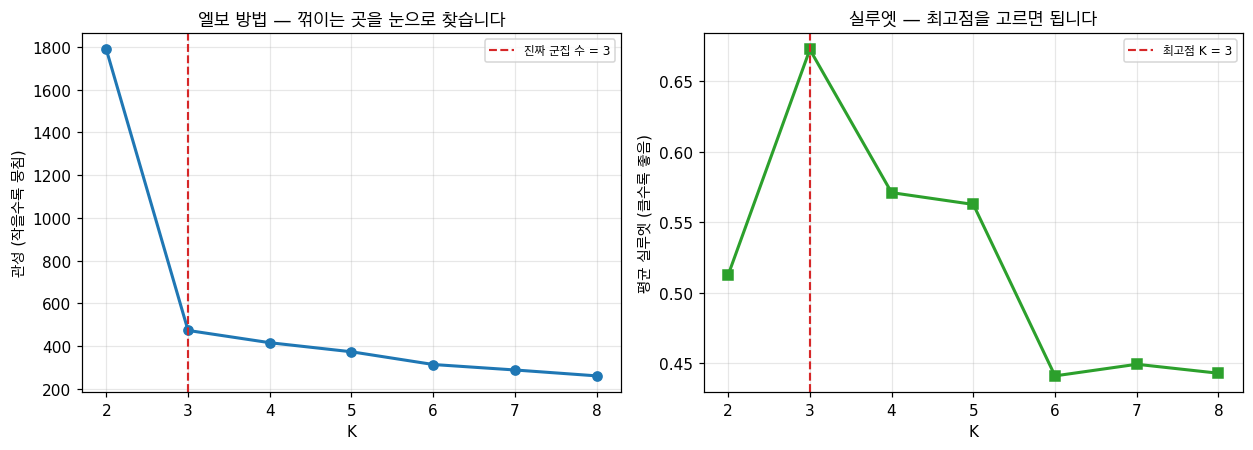

⚠️ 엘보의 단점: '꺾이는 곳'이 애매할 때가 많습니다. 사람이 눈으로 판단해야 해요.
   실루엣은 숫자 하나로 나오니 자동으로 고를 수 있습니다. 대신 계산이 O(n²)라 느립니다.
   (점 300개면 거리 행렬이 300×300 = 90,000칸입니다)


In [10]:
# ✨ 추가 — 엘보와 실루엣을 그림으로
fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.2))
ax[0].plot(K후보, 관성목록, "o-", lw=2)
ax[0].axvline(3, c="tab:red", ls="--", lw=1.4, label="진짜 군집 수 = 3")
ax[0].set_xlabel("K"); ax[0].set_ylabel("관성 (작을수록 뭉침)")
ax[0].set_title("엘보 방법 — 꺾이는 곳을 눈으로 찾습니다")
ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3)

ax[1].plot(K후보, 실루엣목록, "s-", lw=2, c="tab:green")
ax[1].axvline(최고K, c="tab:red", ls="--", lw=1.4, label=f"최고점 K = {최고K}")
ax[1].set_xlabel("K"); ax[1].set_ylabel("평균 실루엣 (클수록 좋음)")
ax[1].set_title("실루엣 — 최고점을 고르면 됩니다")
ax[1].legend(fontsize=8); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print("⚠️ 엘보의 단점: '꺾이는 곳'이 애매할 때가 많습니다. 사람이 눈으로 판단해야 해요.")
print("   실루엣은 숫자 하나로 나오니 자동으로 고를 수 있습니다. 대신 계산이 O(n²)라 느립니다.")
print(f"   (점 {len(X1)}개면 거리 행렬이 {len(X1)}×{len(X1)} = {len(X1)**2:,}칸입니다)")

> ✨ **추가** — 실루엣이 '점 하나하나'에 대해 뭘 말하는지 봅니다. 이게 실루엣의 진짜 쓸모입니다.

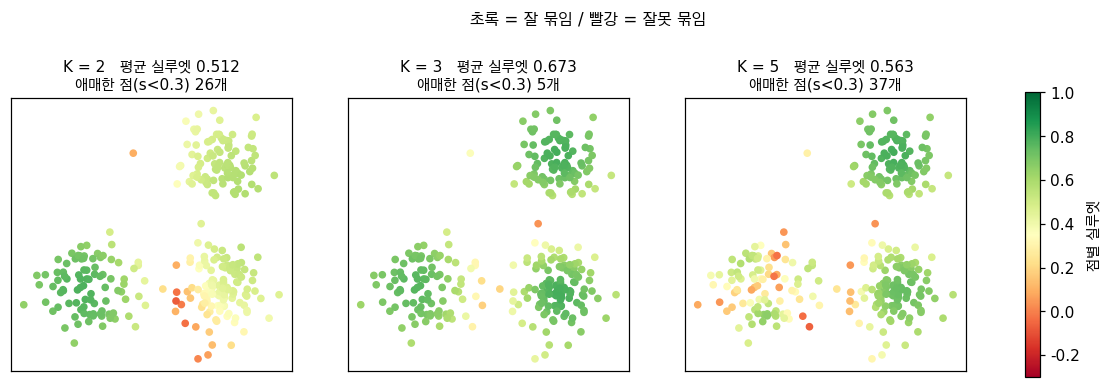

K=2 : 두 덩어리를 억지로 합쳐서 경계 근처가 빨갛습니다.
K=3 : 거의 다 초록입니다.
K=5 : 멀쩡한 덩어리를 쪼개서 경계에 빨간 점이 생깁니다.

=> 평균 하나만 보는 게 아니라 '어느 점이 애매한지'까지 알려 줍니다.
   실무에서는 이 빨간 점들을 따로 꺼내서 살펴봅니다.


In [11]:
# ✨ 추가 — 점별 실루엣 값을 색으로 칠해 봅니다
def 점별실루엣(X, 배정):
    D = np.sqrt(((X[:, None, :] - X[None]) ** 2).sum(-1))
    군집들 = np.unique(배정)
    결과 = np.zeros(len(X))
    for i in range(len(X)):
        내군집 = 배정 == 배정[i]
        if int(내군집.sum()) <= 1:
            continue
        a = D[i, 내군집].sum() / (int(내군집.sum()) - 1)
        b = min(D[i, 배정 == c].mean() for c in 군집들 if c != 배정[i])
        결과[i] = (b - a) / max(a, b)
    return 결과

fig, ax = plt.subplots(1, 3, figsize=(14, 4.2))
for a_, K in zip(ax, [2, 3, 5]):
    m = K평균(K=K, 시드=0, 초기화="kmeans++").학습(X1)
    s = 점별실루엣(X1, m.배정)
    그림 = a_.scatter(X1[:, 0], X1[:, 1], c=s, cmap="RdYlGn", vmin=-0.3, vmax=1.0, s=16)
    a_.set_title(f"K = {K}   평균 실루엣 {s.mean():.3f}\n애매한 점(s<0.3) {int((s<0.3).sum())}개",
                 fontsize=10)
    a_.set_aspect("equal"); a_.set_xticks([]); a_.set_yticks([])
plt.colorbar(그림, ax=ax, shrink=0.8, label="점별 실루엣")
plt.suptitle("초록 = 잘 묶임 / 빨강 = 잘못 묶임", fontsize=11)
plt.show()

print("K=2 : 두 덩어리를 억지로 합쳐서 경계 근처가 빨갛습니다.")
print("K=3 : 거의 다 초록입니다.")
print("K=5 : 멀쩡한 덩어리를 쪼개서 경계에 빨간 점이 생깁니다.")
print("\n=> 평균 하나만 보는 게 아니라 '어느 점이 애매한지'까지 알려 줍니다.")
print("   실무에서는 이 빨간 점들을 따로 꺼내서 살펴봅니다.")

---

## 4️⃣ 🔨 DBSCAN 밑바닥부터

> 📗 **원문** — "DBSCAN: Density-Based Clustering" + "Build It: Step 3"
>
> 🔗 **앞 절과 이어서** — 2절의 약점 두 개(**모양 가정**, **K를 미리 알아야 함**)를
> **한 번에** 없앤 게 DBSCAN입니다. 발상을 통째로 바꿉니다.

### 📗 발상의 전환

K-평균은 **"중심에서 가까운가"**를 물었습니다.
DBSCAN은 **"주변이 빽빽한가"**를 묻습니다.

> 원문: "It finds clusters as dense regions separated by sparse regions."
> (빽빽한 지역이 성긴 지역으로 갈라진 것을 군집으로 봅니다.)

### 🧸 비유 — 밤하늘에서 도시 찾기

비행기에서 밤에 아래를 내려다봅니다. **불빛이 빽빽하게 모인 곳이 도시**죠.
도시가 무슨 **모양**인지는 안 봅니다. 동그랗든 길쭉하든 상관없어요.
그리고 **몇 개 도시가 있는지 미리 알 필요도 없습니다.** 세어 보면 되니까요.
들판에 뚝 떨어진 불빛 하나는? **도시가 아닙니다.** 그게 이상치입니다.

### 📗 손잡이 두 개

- **eps** — "이웃"으로 칠 반지름
- **min_samples** — 빽빽하다고 인정할 최소 이웃 수

### 📗 점을 세 종류로 나눕니다

| 종류 | 조건 | 🧸 비유 |
| --- | --- | --- |
| **핵심점(core)** | 반지름 eps 안에 min_samples개 이상 | **도심** |
| **경계점(border)** | 자기는 부족하지만 핵심점 옆에 있음 | **변두리** |
| **잡음점(noise)** | 둘 다 아님 | **들판의 외딴집 = 이상치** |

핵심점끼리 eps 안에 있으면 **같은 군집으로 연결**됩니다.
경계점은 옆 핵심점의 군집에 **얹혀 갑니다.** 잡음점은 **어디에도 안 들어갑니다.**

### 📗 강점과 약점

| | |
| --- | --- |
| ✅ **강점** | 아무 모양이나 찾음 · **군집 개수 자동** · **이상치 검출** |
| ❌ **약점** | **밀도가 다르면 무너짐** · 아주 높은 차원에서 약함 |

그 약점이 **5절 계층적 군집화**를 부릅니다.

In [12]:
# 📗 원문 Step 3 — DBSCAN
def DBSCAN직접(X, eps=0.5, 최소이웃=5):
    X = np.asarray(X, dtype=float)
    n = len(X)
    D = np.sqrt(((X[:, None, :] - X[None]) ** 2).sum(-1))
    이웃목록 = [np.where(D[i] <= eps)[0] for i in range(n)]      # 자기 자신 포함
    핵심 = np.array([len(이웃목록[i]) >= 최소이웃 for i in range(n)])

    라벨 = np.full(n, -1)          # -1 = 잡음 (아직 아무 데도 안 들어감)
    군집번호 = 0
    for i in range(n):
        if 라벨[i] != -1 or not 핵심[i]:
            continue               # 이미 배정됐거나 핵심점이 아니면 시작점이 될 수 없습니다
        # 이 핵심점에서 출발해 이어진 곳을 전부 같은 군집으로 (너비 우선 탐색)
        라벨[i] = 군집번호
        대기 = list(이웃목록[i])
        while 대기:
            j = 대기.pop()
            if 라벨[j] == -1:
                라벨[j] = 군집번호            # 잡음이었다면 경계점으로 편입
                if 핵심[j]:
                    대기.extend(이웃목록[j])  # ⭐ 핵심점일 때만 더 뻗어 나갑니다
        군집번호 += 1
    return 라벨, 핵심

# sklearn과 결과가 같은지 확인
from sklearn.cluster import DBSCAN
X초, _ = 초승달(0, 300)
내라벨, 내핵심 = DBSCAN직접(X초, eps=0.6, 최소이웃=5)
sk라벨 = DBSCAN(eps=0.6, min_samples=5).fit_predict(X초)

print(f"직접 만든 것 : 군집 {len(set(내라벨)) - (1 if -1 in 내라벨 else 0)}개, "
      f"잡음 {int((내라벨 == -1).sum())}개")
print(f"sklearn     : 군집 {len(set(sk라벨)) - (1 if -1 in sk라벨 else 0)}개, "
      f"잡음 {int((sk라벨 == -1).sum())}개")
print(f"잡음으로 찍은 점이 정확히 같은가: {np.array_equal(내라벨 == -1, sk라벨 == -1)}")
print("\n=> K를 넣지 않았는데 군집 개수가 나왔습니다. 이게 DBSCAN의 첫 번째 장점입니다.")

직접 만든 것 : 군집 2개, 잡음 0개
sklearn     : 군집 2개, 잡음 0개
잡음으로 찍은 점이 정확히 같은가: True

=> K를 넣지 않았는데 군집 개수가 나왔습니다. 이게 DBSCAN의 첫 번째 장점입니다.


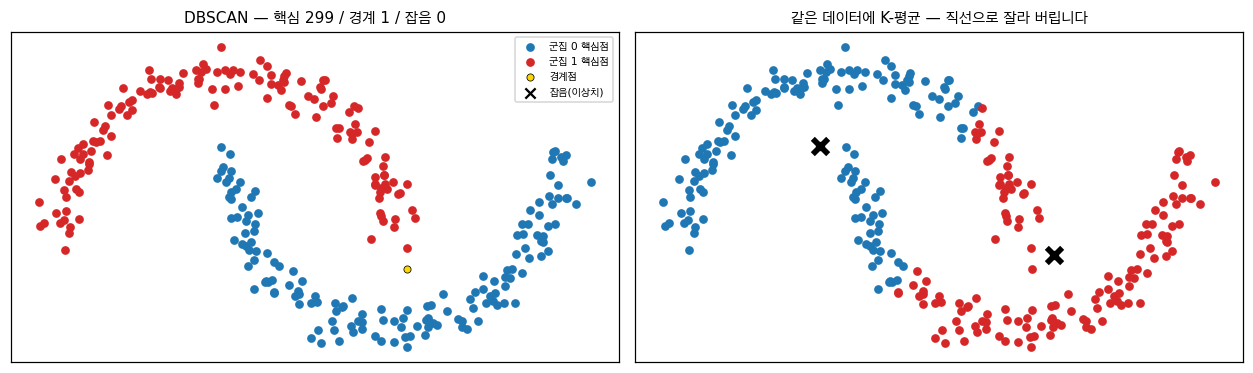

=> 2절에서 K-평균이 못 풀던 초승달을 DBSCAN은 풉니다.
   '중심에서 가까운가' 대신 '옆 점과 이어지는가'를 보기 때문입니다.


In [13]:
# ✨ 추가 — 핵심점 / 경계점 / 잡음점을 색으로 구분해 봅니다
라벨, 핵심 = DBSCAN직접(X초, eps=0.6, 최소이웃=5)
경계 = (~핵심) & (라벨 != -1)
잡음 = 라벨 == -1

fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.6))
for k in sorted(set(라벨) - {-1}):
    골라 = (라벨 == k) & 핵심
    ax[0].scatter(X초[골라, 0], X초[골라, 1], s=22, c=색표[k], label=f"군집 {k} 핵심점")
ax[0].scatter(X초[경계, 0], X초[경계, 1], s=22, c="gold", edgecolors="black",
              linewidths=0.5, label="경계점")
ax[0].scatter(X초[잡음, 0], X초[잡음, 1], s=45, c="black", marker="x", label="잡음(이상치)")
ax[0].set_title(f"DBSCAN — 핵심 {int(핵심.sum())} / 경계 {int(경계.sum())} / 잡음 {int(잡음.sum())}",
                fontsize=10)
ax[0].legend(fontsize=7); ax[0].set_aspect("equal")

# 비교: 같은 데이터에 K-평균
km초 = K평균(K=2, 시드=0, 초기화="kmeans++").학습(X초)
for k in range(2):
    ax[1].scatter(X초[km초.배정 == k, 0], X초[km초.배정 == k, 1], s=22, c=색표[k])
ax[1].scatter(km초.중심[:, 0], km초.중심[:, 1], s=220, c="black", marker="X",
              edgecolors="white", linewidths=1.5)
ax[1].set_title("같은 데이터에 K-평균 — 직선으로 잘라 버립니다", fontsize=10)
ax[1].set_aspect("equal")
for a_ in ax:
    a_.set_xticks([]); a_.set_yticks([])
plt.tight_layout(); plt.show()

print("=> 2절에서 K-평균이 못 풀던 초승달을 DBSCAN은 풉니다.")
print("   '중심에서 가까운가' 대신 '옆 점과 이어지는가'를 보기 때문입니다.")

> ✨ **추가** — DBSCAN의 손잡이 eps가 얼마나 예민한지, 그리고 약점(밀도 차이)을 확인합니다.

In [14]:
# ✨ 추가 — eps를 바꾸면 결과가 얼마나 달라지나
print(f"{'eps':>7}{'군집 수':>10}{'잡음 점':>10}   결과")
print("-" * 50)
for eps in [0.2, 0.4, 0.6, 1.0, 2.0, 4.0]:
    l, _ = DBSCAN직접(X초, eps=eps, 최소이웃=5)
    군집수 = len(set(l) - {-1})
    잡음수 = int((l == -1).sum())
    if 군집수 == 0:
        평 = "전부 잡음. eps가 너무 작습니다"
    elif 군집수 == 1:
        평 = "다 한 덩어리. eps가 너무 큽니다"
    elif 군집수 == 2:
        평 = "<- 우리가 원하던 답"
    else:
        평 = "너무 잘게 쪼개짐"
    print(f"{eps:>7}{군집수:>10}{잡음수:>10}   {평}")

print("\n⚠️ eps 하나에 결과가 완전히 달라집니다. K-평균의 K만큼이나 까다로운 손잡이예요.")
print("   'K를 안 정해도 된다'는 장점이 공짜는 아니었습니다. 손잡이가 바뀐 것뿐입니다.")

    eps      군집 수      잡음 점   결과
--------------------------------------------------
    0.2        20       160   너무 잘게 쪼개짐
    0.4         2         4   <- 우리가 원하던 답
    0.6         2         0   <- 우리가 원하던 답
    1.0         1         0   다 한 덩어리. eps가 너무 큽니다
    2.0         1         0   다 한 덩어리. eps가 너무 큽니다
    4.0         1         0   다 한 덩어리. eps가 너무 큽니다

⚠️ eps 하나에 결과가 완전히 달라집니다. K-평균의 K만큼이나 까다로운 손잡이예요.
   'K를 안 정해도 된다'는 장점이 공짜는 아니었습니다. 손잡이가 바뀐 것뿐입니다.


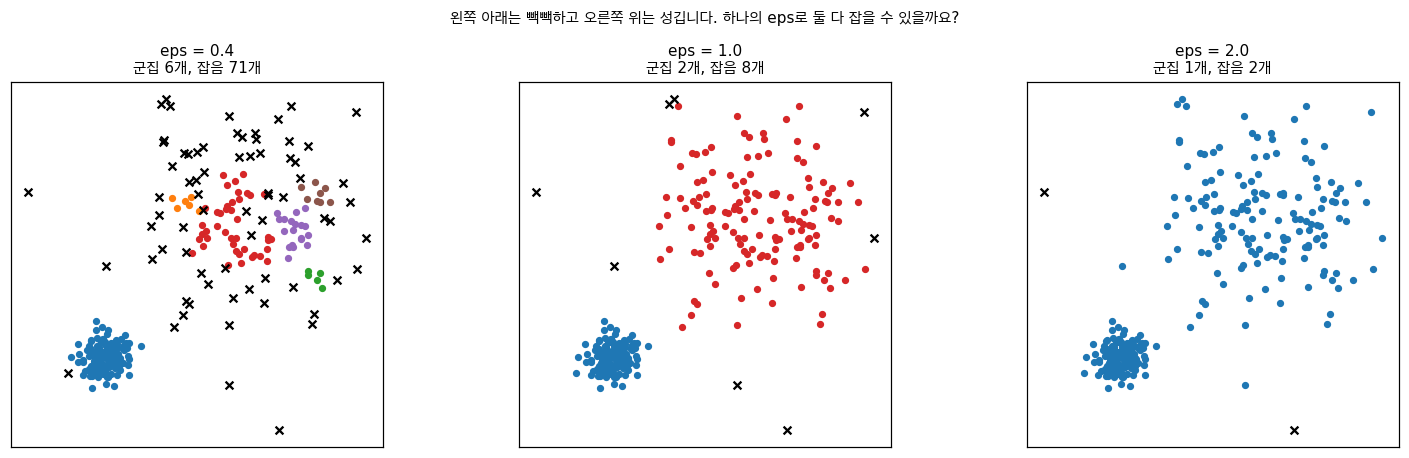

eps를 작게 → 빽빽한 쪽만 잡고 성긴 쪽은 통째로 잡음 처리됩니다.
eps를 크게 → 성긴 쪽은 잡히지만 빽빽한 쪽이 이웃과 합쳐집니다.

=> 📗 원문의 'struggles with clusters of varying densities'가 이겁니다.
   eps가 '전 지역 공통'이라서 생기는 한계예요. (HDBSCAN이 이걸 개선한 방법입니다)


In [15]:
# ✨ 추가 — DBSCAN의 진짜 약점: 밀도가 다를 때
X밀도, _ = 밀도다름(0, 300)

fig, ax = plt.subplots(1, 3, figsize=(14, 4.2))
for a_, eps in zip(ax, [0.4, 1.0, 2.0]):
    l, _ = DBSCAN직접(X밀도, eps=eps, 최소이웃=5)
    for k in sorted(set(l) - {-1}):
        a_.scatter(X밀도[l == k, 0], X밀도[l == k, 1], s=14, c=색표[k % len(색표)])
    a_.scatter(X밀도[l == -1, 0], X밀도[l == -1, 1], s=26, c="black", marker="x")
    a_.set_title(f"eps = {eps}\n군집 {len(set(l)-{-1})}개, 잡음 {int((l==-1).sum())}개",
                 fontsize=10)
    a_.set_aspect("equal"); a_.set_xticks([]); a_.set_yticks([])
plt.suptitle("왼쪽 아래는 빽빽하고 오른쪽 위는 성깁니다. 하나의 eps로 둘 다 잡을 수 있을까요?",
             fontsize=10)
plt.tight_layout(); plt.show()

print("eps를 작게 → 빽빽한 쪽만 잡고 성긴 쪽은 통째로 잡음 처리됩니다.")
print("eps를 크게 → 성긴 쪽은 잡히지만 빽빽한 쪽이 이웃과 합쳐집니다.")
print("\n=> 📗 원문의 'struggles with clusters of varying densities'가 이겁니다.")
print("   eps가 '전 지역 공통'이라서 생기는 한계예요. (HDBSCAN이 이걸 개선한 방법입니다)")

---

## 5️⃣ 계층적 군집화 — 덴드로그램

> 📗 **원문** — "Hierarchical Clustering"
>
> 🔗 **앞 절과 이어서** — K-평균은 **K를 미리** 정해야 했고, DBSCAN은 **eps를 미리** 정해야 했습니다.
> 둘 다 "먼저 정하고 결과를 본다"는 점은 같습니다.
> 계층적 군집화는 순서를 뒤집습니다. **먼저 다 만들어 놓고, 보고 나서 자릅니다.**

### 📗 병합형(bottom-up) 알고리즘

1. **점 하나하나를 각각 군집**으로 시작합니다 (n개 군집)
2. **가장 가까운 두 군집을 합칩니다**
3. 하나가 남을 때까지 **반복**합니다
4. 원하는 높이에서 **나무를 자르면** 그게 K개 군집입니다

### 🧸 비유 — 가족 계보도

나 → 형제 → 사촌 → 친척 → … 이렇게 위로 올라가며 묶이는 나무가 만들어집니다.
"몇 촌까지를 한 가족으로 볼까?"를 **나무를 다 그린 다음에** 정하면 됩니다.

이 나무 그림을 **덴드로그램**이라고 부릅니다.

### 📗 "가깝다"를 군집 사이에 어떻게 재나 — 연결(linkage)

| 방식 | 재는 법 | 성격 |
| --- | --- | --- |
| **단일(single)** | 두 군집에서 **가장 가까운 두 점** 거리 | 길쭉한 모양을 잘 따라감. 사슬처럼 늘어짐 |
| **완전(complete)** | **가장 먼 두 점** 거리 | 동글동글한 덩어리를 만듦 |
| **평균(average)** | 모든 쌍의 **평균** 거리 | 중간 |
| **와드(Ward)** | 합쳤을 때 **분산 증가가 가장 작은** 쌍 | 가장 많이 씀. K-평균과 비슷한 결과 |

### ❌ 약점

**$O(n^2)$ 메모리**를 씁니다. 모든 점 쌍의 거리를 들고 있어야 하니까요.
점 10만 개면 거리 행렬이 100억 칸입니다. **큰 데이터에는 못 씁니다.**

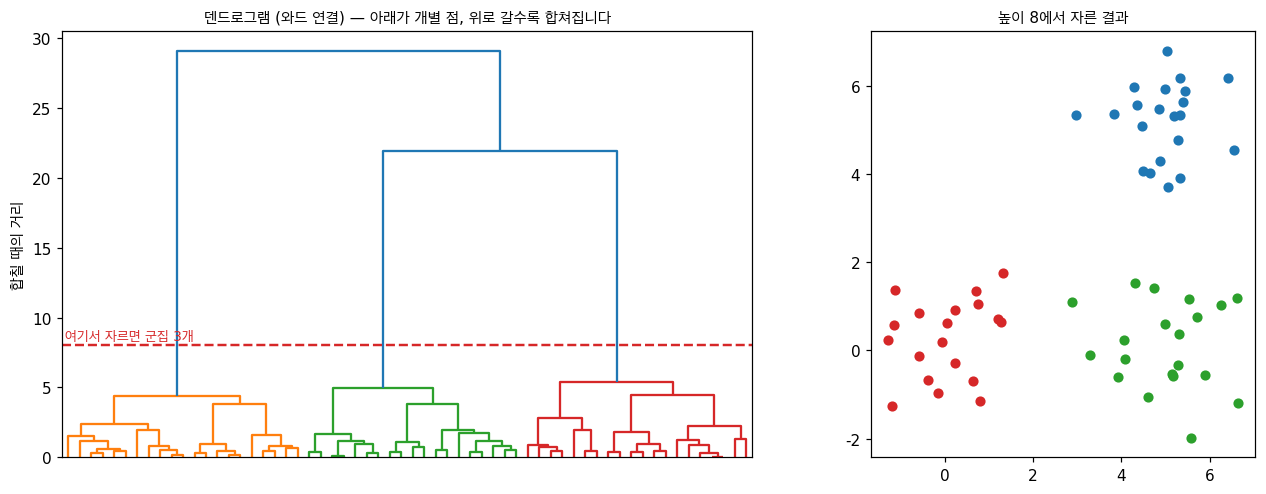

=> 나무를 '얼마나 높은 곳에서 자르느냐'가 곧 K입니다.
   K를 미리 정하는 게 아니라, 나무를 보고 '여기가 자연스럽네' 하고 정할 수 있습니다.
   세로축이 크게 벌어지는 구간이 있으면, 그 사이가 자를 만한 곳입니다.


In [16]:
# 📗 원문 — 계층적 군집화 (scipy로 덴드로그램까지 그립니다)
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

X작게, _ = 덩어리(0, 60)          # 덴드로그램은 점이 적어야 읽힙니다

fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
Z = linkage(X작게, method="ward")
dendrogram(Z, ax=ax[0], no_labels=True, color_threshold=8.0)
ax[0].axhline(8.0, c="tab:red", ls="--", lw=1.6)
ax[0].text(2, 8.4, "여기서 자르면 군집 3개", color="tab:red", fontsize=9)
ax[0].set_title("덴드로그램 (와드 연결) — 아래가 개별 점, 위로 갈수록 합쳐집니다", fontsize=10)
ax[0].set_ylabel("합칠 때의 거리")

잘라낸 = fcluster(Z, t=3, criterion="maxclust")
for k in np.unique(잘라낸):
    ax[1].scatter(X작게[잘라낸 == k, 0], X작게[잘라낸 == k, 1], s=32, c=색표[k-1])
ax[1].set_title("높이 8에서 자른 결과", fontsize=10)
ax[1].set_aspect("equal")
plt.tight_layout(); plt.show()

print("=> 나무를 '얼마나 높은 곳에서 자르느냐'가 곧 K입니다.")
print("   K를 미리 정하는 게 아니라, 나무를 보고 '여기가 자연스럽네' 하고 정할 수 있습니다.")
print("   세로축이 크게 벌어지는 구간이 있으면, 그 사이가 자를 만한 곳입니다.")

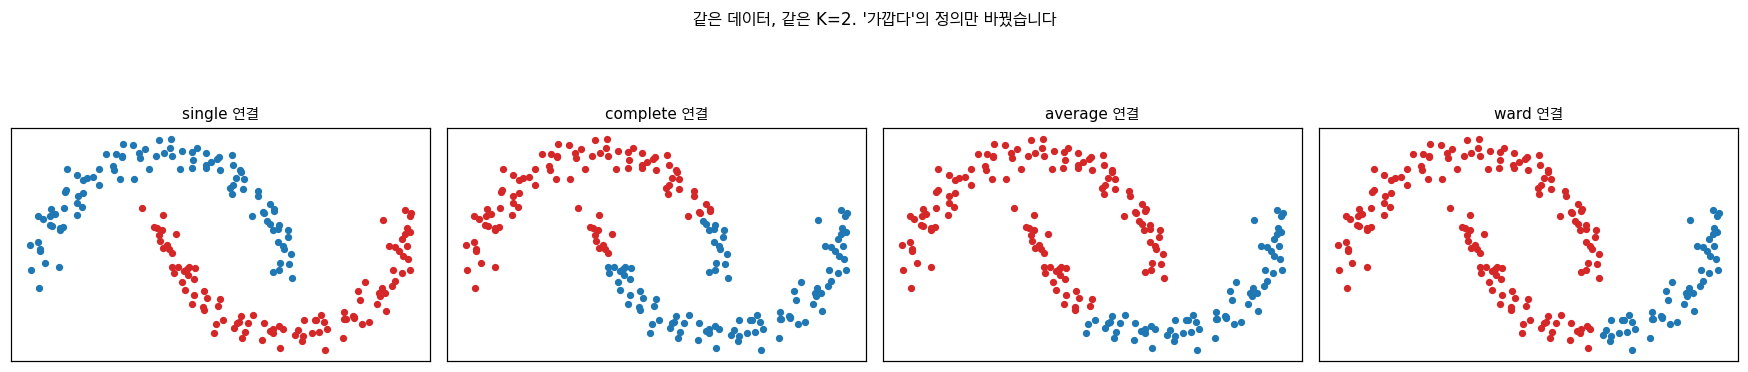

single  : 초승달을 제대로 나눕니다. '가장 가까운 두 점'만 보니 사슬처럼 따라가거든요.
complete·ward : 동글동글하게 잘라 버립니다. K-평균이 한 것과 비슷하죠.

=> 같은 알고리즘인데 연결 방식 하나로 성격이 완전히 달라집니다.
   0절의 질문이 다시 나옵니다. '비슷하다'를 뭐로 정할 것인가.


In [17]:
# ✨ 추가 — 연결 방식 네 가지를 초승달 데이터에 붙여 봅니다
X초작게, _ = 초승달(0, 200)
fig, ax = plt.subplots(1, 4, figsize=(16, 4.1))
for a_, 방식 in zip(ax, ["single", "complete", "average", "ward"]):
    Zi = linkage(X초작게, method=방식)
    l = fcluster(Zi, t=2, criterion="maxclust")
    for k in np.unique(l):
        a_.scatter(X초작게[l == k, 0], X초작게[l == k, 1], s=14, c=색표[k-1])
    a_.set_title(f"{방식} 연결", fontsize=10)
    a_.set_aspect("equal"); a_.set_xticks([]); a_.set_yticks([])
plt.suptitle("같은 데이터, 같은 K=2. '가깝다'의 정의만 바꿨습니다", fontsize=11)
plt.tight_layout(); plt.show()

print("single  : 초승달을 제대로 나눕니다. '가장 가까운 두 점'만 보니 사슬처럼 따라가거든요.")
print("complete·ward : 동글동글하게 잘라 버립니다. K-평균이 한 것과 비슷하죠.")
print("\n=> 같은 알고리즘인데 연결 방식 하나로 성격이 완전히 달라집니다.")
print("   0절의 질문이 다시 나옵니다. '비슷하다'를 뭐로 정할 것인가.")

---

## 6️⃣ 🔨 GMM과 EM — 부드러운 배정

> 📗 **원문** — "Gaussian Mixture Models (GMM)" + "Build It: Step 4"
>
> 🔗 **앞 절과 이어서** — 여기까지 세 알고리즘은 전부 **"이 점은 1번 군집"**이라고
> 딱 잘라 말했습니다(**하드 배정**). 그런데 **두 군집 경계에 딱 걸친 점**은요?
> **"70%는 1번 같고 30%는 2번 같습니다"**라고 말하는 게 더 정직하지 않을까요?

### 📗 GMM의 발상

> 원문: "GMM assumes the data is generated from a mixture of K Gaussian distributions."

**"이 데이터는 사실 정규분포 K개에서 뽑혀 나온 것"**이라고 가정합니다.
각 정규분포는 자기 **평균**(어디에)과 **공분산**(어떤 모양으로 퍼졌나)을 가집니다.

### 🧸 비유 — 물감 K통을 섞어 뿌린 자국

빨강·파랑·초록 물감을 각각 다른 자리에 다른 크기로 뿌렸습니다.
말라붙은 자국만 보고 **"각 물감이 어디에 얼마나 퍼져 있었나"**를 되짚는 겁니다.
가운데 겹친 부분의 점 하나는 **"빨강 60%, 파랑 40%"** 정도로 말할 수 있죠.

### 📗 EM 알고리즘 — 닭이 먼저냐 달걀이 먼저냐

문제가 하나 있습니다.

- **각 점이 어느 분포에서 왔는지 알면** → 분포의 평균·공분산을 구할 수 있습니다
- **분포를 알면** → 각 점이 어디서 왔는지 확률을 구할 수 있습니다

**둘 다 모릅니다.** 그래서 번갈아 가며 조금씩 개선합니다.

| 단계 | 하는 일 | 🧸 |
| --- | --- | --- |
| **E단계** (Expectation) | 지금 분포를 믿고, **각 점이 각 분포에 속할 확률**을 계산 | "지금 아는 대로 점들을 나눠 보자" |
| **M단계** (Maximization) | 그 확률로 가중해서 **평균·공분산·비중을 갱신** | "나눈 대로 분포를 다시 그리자" |

이걸 반복하면 **우도(likelihood)가 계속 올라갑니다.** K-평균과 똑같은 구조예요.

> 🔑 **사실 K-평균은 GMM의 특수한 경우입니다.**
> 확률을 0 아니면 1로 딱 자르고, 모든 분포가 같은 크기의 **완전한 원**이라고 두면 K-평균이 됩니다.
> GMM은 그 제약을 풀어서 **타원**도 되고 **확률**도 됩니다.

In [18]:
# 📗 원문 Step 4 — GMM (EM 알고리즘)
class GMM:
    def __init__(self, K=3, 최대반복=200, 시드=0, 허용오차=1e-6):
        self.K = K
        self.최대반복 = 최대반복
        self.시드 = 시드
        self.허용오차 = 허용오차

    def _정규분포밀도(self, X, 평균, 공분산):
        d = X.shape[1]
        차이 = X - 평균
        역행렬 = np.linalg.inv(공분산)
        지수 = -0.5 * np.einsum("ij,jk,ik->i", 차이, 역행렬, 차이)
        앞 = 1.0 / np.sqrt(((2 * np.pi) ** d) * np.linalg.det(공분산))
        return 앞 * np.exp(지수)

    def 학습(self, X):
        X = np.asarray(X, dtype=float)
        n, d = X.shape
        rng = np.random.default_rng(self.시드)

        # 시작값: 평균은 아무 점 K개, 공분산은 전체 공분산, 비중은 균등
        self.평균 = X[rng.choice(n, self.K, replace=False)].copy()
        self.공분산 = np.array([np.cov(X.T) + np.eye(d) * 1e-6 for _ in range(self.K)])
        self.비중 = np.full(self.K, 1.0 / self.K)
        self.로그우도기록 = []

        직전 = -np.inf
        for 회차 in range(self.최대반복):
            # ── E단계: 각 점이 각 분포에 속할 확률(책임도)
            밀도 = np.array([self.비중[k] * self._정규분포밀도(X, self.평균[k], self.공분산[k])
                            for k in range(self.K)]).T          # (n, K)
            합 = 밀도.sum(axis=1, keepdims=True) + 1e-300
            책임도 = 밀도 / 합

            로그우도 = float(np.log(합).sum())
            self.로그우도기록.append(로그우도)

            # ── M단계: 책임도로 가중해서 평균·공분산·비중을 다시 계산
            무게합 = 책임도.sum(axis=0) + 1e-10                  # (K,)
            self.비중 = 무게합 / n
            self.평균 = (책임도.T @ X) / 무게합[:, None]
            for k in range(self.K):
                차이 = X - self.평균[k]
                self.공분산[k] = ((책임도[:, k, None] * 차이).T @ 차이) / 무게합[k]
                self.공분산[k] += np.eye(d) * 1e-6               # 뒤집을 수 있게 살짝 보태 줍니다

            if abs(로그우도 - 직전) < self.허용오차:
                break
            직전 = 로그우도

        self.책임도 = 책임도
        self.배정 = 책임도.argmax(axis=1)      # 딱 잘라 말해야 할 때는 가장 큰 걸로
        self.반복횟수 = 회차 + 1
        return self

    def 확률(self, X):
        X = np.asarray(X, dtype=float)
        밀도 = np.array([self.비중[k] * self._정규분포밀도(X, self.평균[k], self.공분산[k])
                        for k in range(self.K)]).T
        return 밀도 / (밀도.sum(axis=1, keepdims=True) + 1e-300)

print("GMM 준비 완료")

GMM 준비 완료


In [19]:
# 확인: sklearn과 로그우도가 비슷한지
from sklearn.mixture import GaussianMixture

내GMM = GMM(K=3, 시드=0).학습(X1)
skGMM = GaussianMixture(n_components=3, random_state=0).fit(X1)

print(f"직접 만든 GMM : 반복 {내GMM.반복횟수}번, 로그우도 {내GMM.로그우도기록[-1]:.3f}")
print(f"sklearn GMM  : 로그우도 {skGMM.score(X1) * len(X1):.3f}")
print("=> 값이 비슷하면 같은 곳으로 수렴한 겁니다.\n")

print("로그우도가 매 반복 올라가는지 확인 (EM의 보장입니다)")
기록 = 내GMM.로그우도기록
내려간적 = sum(1 for i in range(1, len(기록)) if 기록[i] < 기록[i-1] - 1e-9)
print(f"  {기록[0]:.2f} -> {기록[-1]:.2f}")
print(f"  중간에 내려간 횟수: {내려간적}번")
print("  => 0번이어야 정상입니다. EM은 '절대 나빠지지 않음'이 수학적으로 보장됩니다.")

직접 만든 GMM : 반복 83번, 로그우도 -1102.428
sklearn GMM  : 로그우도 -1102.429
=> 값이 비슷하면 같은 곳으로 수렴한 겁니다.

로그우도가 매 반복 올라가는지 확인 (EM의 보장입니다)
  -1475.05 -> -1102.43
  중간에 내려간 횟수: 0번
  => 0번이어야 정상입니다. EM은 '절대 나빠지지 않음'이 수학적으로 보장됩니다.


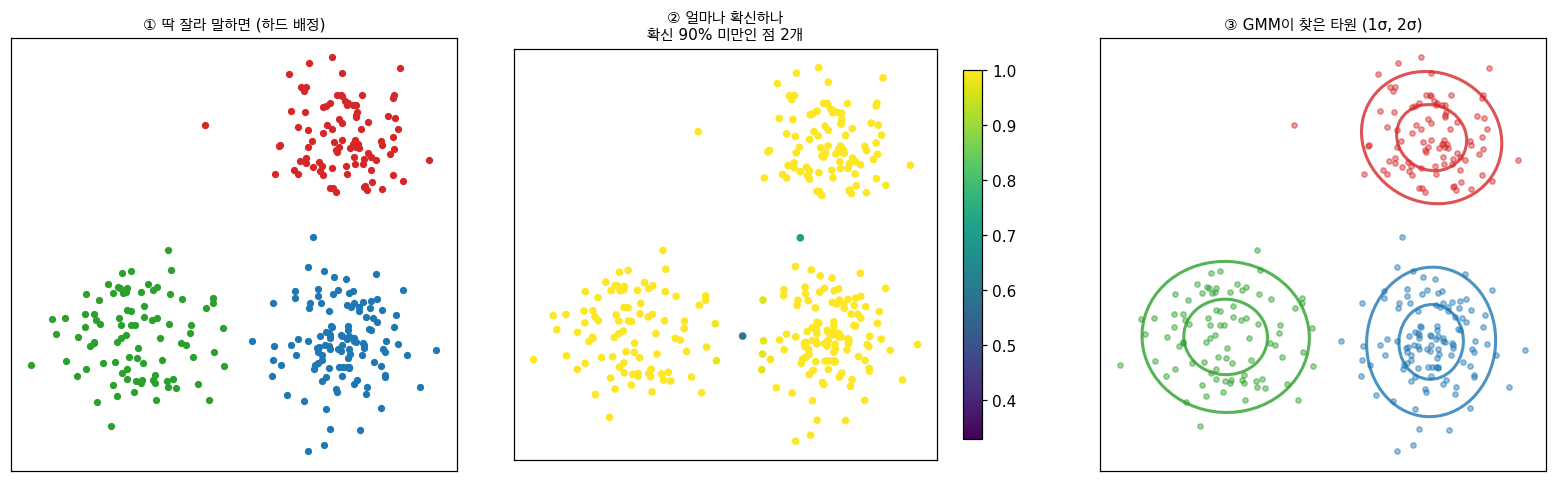

가장 애매한 점: [ 2.76 -0.07]
  이 점의 소속 확률 = [0.601 0.    0.399]
  => '0번 군집'이라고 딱 잘라 말하기엔 근거가 약합니다.
     K-평균은 이런 점도 무조건 하나로 배정합니다. GMM은 '애매하다'고 알려 줍니다.

💡 실무에서 이게 중요합니다. 고객을 분류할 때 '이 고객은 애매하니 사람이 보자'가 가능해집니다.


In [20]:
# ✨ 추가 — '부드러운 배정'이 뭔지 눈으로 봅니다
확률 = 내GMM.책임도
최대확률 = 확률.max(axis=1)
애매한점 = 최대확률 < 0.9

fig, ax = plt.subplots(1, 3, figsize=(15, 4.4))

# ① 하드 배정 (K-평균처럼)
for k in range(3):
    ax[0].scatter(X1[내GMM.배정 == k, 0], X1[내GMM.배정 == k, 1], s=14, c=색표[k])
ax[0].set_title("① 딱 잘라 말하면 (하드 배정)", fontsize=10)

# ② 확신도로 색칠
그림 = ax[1].scatter(X1[:, 0], X1[:, 1], c=최대확률, cmap="viridis", s=16, vmin=0.33, vmax=1.0)
ax[1].set_title(f"② 얼마나 확신하나\n확신 90% 미만인 점 {int(애매한점.sum())}개", fontsize=10)
plt.colorbar(그림, ax=ax[1], shrink=0.85)

# ③ 타원 그리기
for k in range(3):
    값, 벡터 = np.linalg.eigh(내GMM.공분산[k])
    각도 = math.degrees(math.atan2(벡터[1, -1],벡터[0, -1]))
    for 배수 in [1, 2]:
        폭, 높이 = 2 * 배수 * np.sqrt(값[::-1])
        타원 = Ellipse(내GMM.평균[k], 폭, 높이, angle=각도,
                                          fill=False, color=색표[k], lw=2, alpha=0.8)
        ax[2].add_patch(타원)
    ax[2].scatter(X1[내GMM.배정 == k, 0], X1[내GMM.배정 == k, 1], s=12, c=색표[k], alpha=0.45)
ax[2].set_title("③ GMM이 찾은 타원 (1σ, 2σ)", fontsize=10)

for a_ in ax:
    a_.set_aspect("equal"); a_.set_xticks([]); a_.set_yticks([])
plt.tight_layout(); plt.show()

가장애매 = int(np.argmin(최대확률))
print(f"가장 애매한 점: {np.round(X1[가장애매], 2)}")
print(f"  이 점의 소속 확률 = {np.round(확률[가장애매], 3)}")
print(f"  => '{확률[가장애매].argmax()}번 군집'이라고 딱 잘라 말하기엔 근거가 약합니다.")
print("     K-평균은 이런 점도 무조건 하나로 배정합니다. GMM은 '애매하다'고 알려 줍니다.")
print("\n💡 실무에서 이게 중요합니다. 고객을 분류할 때 '이 고객은 애매하니 사람이 보자'가 가능해집니다.")

> ✨ **추가** — GMM은 성분 수 K를 어떻게 고를까요? 3절의 실루엣이 아니라 **BIC**를 씁니다.

### 🔑 왜 실루엣이 아니라 BIC인가요?

GMM은 **확률 모델**입니다. 그래서 "이 데이터가 이 모델에서 나올 가능성"(우도)을 직접 잴 수 있습니다.
문제는 **성분을 늘리면 우도가 무조건 올라간다**는 것입니다. 3절 엘보에서 본 관성과 똑같은 함정이죠.

**BIC**는 거기에 **복잡도 벌점**을 붙입니다.

$$\text{BIC} = -2\ln(\text{우도}) + k \ln(n)$$

- $k$ = 모델이 쓰는 파라미터 개수 (성분이 늘면 커집니다)
- $n$ = 데이터 개수

**BIC가 가장 작은 K**를 고르면 됩니다. 엘보처럼 사람이 눈대중할 필요가 없어요.

> **AIC**는 벌점이 $2k$ 로 더 약합니다. 그래서 **AIC는 성분을 더 많이 고르는 경향**이 있습니다.

   K         로그우도       파라미터 수         BIC         AIC        실루엣
------------------------------------------------------------------
   1      -1374.3            5      2777.1      2758.6        nan
   2      -1193.2           11      2449.2      2408.4     0.5159
   3      -1102.4           17      2301.8      2238.9     0.6723
   4      -1100.6           23      2332.3      2247.1     0.5428
   5      -1095.1           29      2355.5      2248.1     0.4436
   6      -1090.0           35      2379.6      2250.0     0.4311
   7      -1088.3           41      2410.5      2258.6     0.3242
   8      -1085.9           47      2439.9      2265.8     0.3286

BIC 가 고른 K = 3   (진짜 정답은 3)
AIC 가 고른 K = 3

=> '로그우도' 열을 보세요. K를 늘리면 계속 올라갑니다. 우도만으론 K를 못 고릅니다.
   BIC는 파라미터 수에 벌점을 매겨서 최솟값이 생깁니다. 그 지점을 고르면 됩니다.
   AIC(3)와 BIC(3)를 비교해 보세요. 이 데이터에서는 둘이 같습니다.


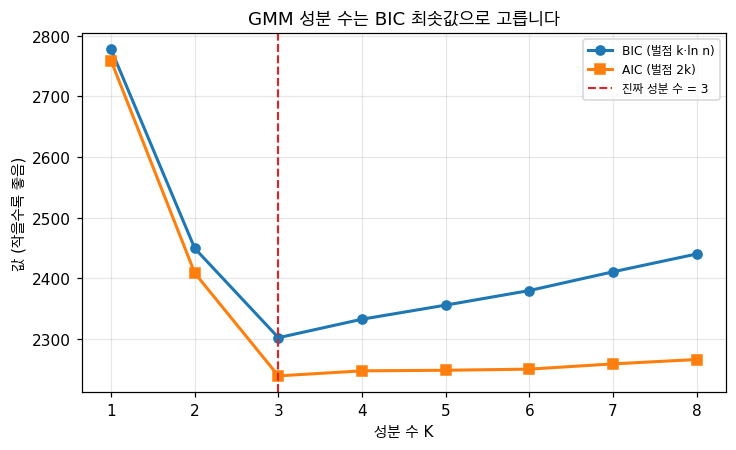


💡 정리 — 3절의 지표들과 역할이 다릅니다.
   · 엘보(관성) : K-평균용. 꺾이는 곳을 사람이 눈으로 찾아야 합니다
   · 실루엣      : 아무 군집화에나 쓸 수 있습니다. 동그란 군집에 유리 (7절에서 확인)
   · BIC/AIC    : **확률 모델(GMM)에만** 쓸 수 있습니다. 최솟값을 자동으로 고를 수 있습니다


In [21]:
# ✨ 추가 — BIC/AIC 로 GMM 성분 수를 고릅니다
from sklearn.mixture import GaussianMixture as sk가우시안

K후보 = list(range(1, 9))
print(f"{'K':>4}{'로그우도':>13}{'파라미터 수':>13}{'BIC':>12}{'AIC':>12}{'실루엣':>11}")
print("-" * 66)
BIC들, AIC들 = [], []
for K in K후보:
    gm = sk가우시안(n_components=K, random_state=0).fit(X1)
    BIC들.append(gm.bic(X1)); AIC들.append(gm.aic(X1))
    # 파라미터 수 = 평균(K·d) + 공분산(K·d(d+1)/2) + 비중(K-1)
    d = X1.shape[1]
    파라미터 = K * d + K * d * (d + 1) // 2 + (K - 1)
    실루엣 = 실루엣점수(X1, gm.predict(X1)) if K >= 2 else float("nan")
    print(f"{K:>4}{gm.score(X1)*len(X1):>13.1f}{파라미터:>13}"
          f"{gm.bic(X1):>12.1f}{gm.aic(X1):>12.1f}{실루엣:>11.4f}")

BIC최적 = K후보[int(np.argmin(BIC들))]
AIC최적 = K후보[int(np.argmin(AIC들))]
print(f"\nBIC 가 고른 K = {BIC최적}   (진짜 정답은 3)")
print(f"AIC 가 고른 K = {AIC최적}")
print("\n=> '로그우도' 열을 보세요. K를 늘리면 계속 올라갑니다. 우도만으론 K를 못 고릅니다.")
print("   BIC는 파라미터 수에 벌점을 매겨서 최솟값이 생깁니다. 그 지점을 고르면 됩니다.")
print(f"   AIC({AIC최적})와 BIC({BIC최적})를 비교해 보세요. "
      f"{'AIC가 더 많은 성분을 골랐습니다' if AIC최적 > BIC최적 else '이 데이터에서는 둘이 같습니다'}.")

plt.figure(figsize=(6.8, 4.2))
plt.plot(K후보, BIC들, "o-", lw=2, label="BIC (벌점 k·ln n)")
plt.plot(K후보, AIC들, "s-", lw=2, label="AIC (벌점 2k)")
plt.axvline(3, c="tab:red", ls="--", lw=1.4, label="진짜 성분 수 = 3")
plt.xlabel("성분 수 K"); plt.ylabel("값 (작을수록 좋음)")
plt.title("GMM 성분 수는 BIC 최솟값으로 고릅니다")
plt.legend(fontsize=8); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print("\n💡 정리 — 3절의 지표들과 역할이 다릅니다.")
print("   · 엘보(관성) : K-평균용. 꺾이는 곳을 사람이 눈으로 찾아야 합니다")
print("   · 실루엣      : 아무 군집화에나 쓸 수 있습니다. 동그란 군집에 유리 (7절에서 확인)")
print("   · BIC/AIC    : **확률 모델(GMM)에만** 쓸 수 있습니다. 최솟값을 자동으로 고를 수 있습니다")

> ✨ **추가** — 'K-평균은 원, GMM은 타원'을 확인합니다. 길쭉한 덩어리를 만들어 붙여 봅니다.

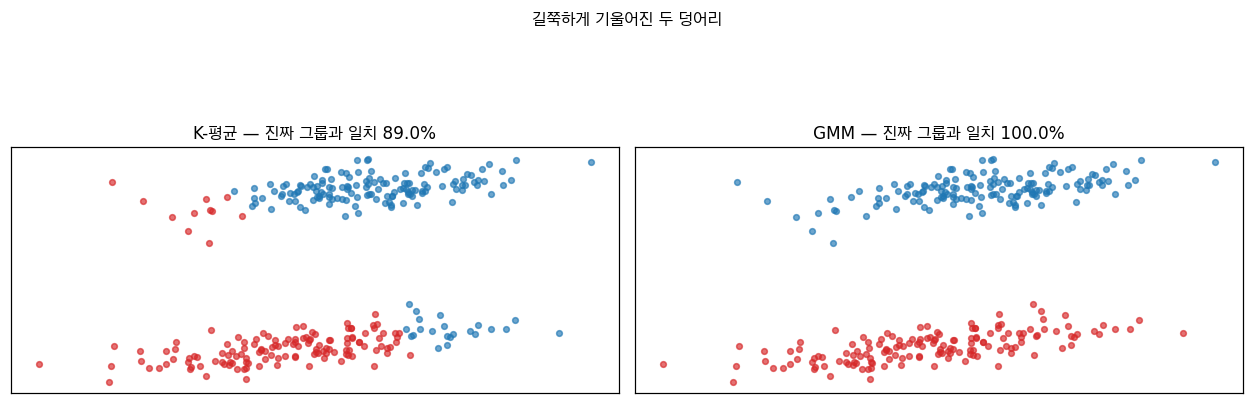

K-평균 89.0%  vs  GMM 100.0%  (차이 +11.0%)

=> K-평균은 '가장 가까운 중심'이라 경계가 항상 직선이고, 군집 모양이 사실상 원입니다.
   GMM은 공분산 행렬을 각자 학습하니까 기울어진 타원도 그대로 잡아냅니다.


In [22]:
# ✨ 추가 — 길쭉한(타원) 덩어리에서 둘을 비교합니다
r = np.random.default_rng(0)
기울이기 = np.array([[2.2, 0.0], [1.6, 0.45]])       # 데이터를 길쭉하게 늘리는 변환
A = r.normal(size=(150, 2)) @ 기울이기 + [0, 0]
B = r.normal(size=(150, 2)) @ 기울이기 + [1.5, 5.0]
X타원 = np.vstack([A, B])
진짜 = np.array([0]*150 + [1]*150)

fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.6))
kmT = K평균(K=2, 시드=0, 초기화="kmeans++").학습(X타원)
gmT = GMM(K=2, 시드=0).학습(X타원)

for a_, (이름, 배정) in zip(ax, [("K-평균", kmT.배정), ("GMM", gmT.배정)]):
    for k in range(2):
        a_.scatter(X타원[배정 == k, 0], X타원[배정 == k, 1], s=14, c=색표[k], alpha=0.65)
    맞음 = max(np.mean(배정 == 진짜), np.mean(배정 != 진짜))    # 번호 순서는 무시
    a_.set_title(f"{이름} — 진짜 그룹과 일치 {맞음:.1%}", fontsize=11)
    a_.set_aspect("equal"); a_.set_xticks([]); a_.set_yticks([])
plt.suptitle("길쭉하게 기울어진 두 덩어리", fontsize=11)
plt.tight_layout(); plt.show()

km맞음 = max(np.mean(kmT.배정 == 진짜), np.mean(kmT.배정 != 진짜))
gm맞음 = max(np.mean(gmT.배정 == 진짜), np.mean(gmT.배정 != 진짜))
print(f"K-평균 {km맞음:.1%}  vs  GMM {gm맞음:.1%}  (차이 {gm맞음-km맞음:+.1%})")
print("\n=> K-평균은 '가장 가까운 중심'이라 경계가 항상 직선이고, 군집 모양이 사실상 원입니다.")
print("   GMM은 공분산 행렬을 각자 학습하니까 기울어진 타원도 그대로 잡아냅니다.")

---

## 7️⃣ 어떤 걸 언제 쓰나

> 📗 **원문** — "When to Use Which"
>
> 🔗 **앞 절과 이어서** — 네 알고리즘을 다 만들었습니다.
> 이제 **같은 데이터 네 종류에 한꺼번에 붙여서** 성격을 눈으로 비교합니다.

| 방법 | 잘하는 것 | 피해야 할 때 |
| --- | --- | --- |
| **K-평균** | 큰 데이터, 동그란 군집, **K를 아는 경우** | 이상한 모양, 이상치가 있을 때 |
| **DBSCAN** | **K를 모를 때**, 아무 모양, **이상치 검출** | 밀도가 제각각, 아주 높은 차원 |
| **계층적** | 작은 데이터, **덴드로그램이 필요**할 때, K를 모를 때 | 큰 데이터 ($O(n^2)$ 메모리) |
| **GMM** | 겹치는 군집, **확률이 필요**할 때, 타원 모양 | 아주 큰 데이터, 너무 높은 차원 |

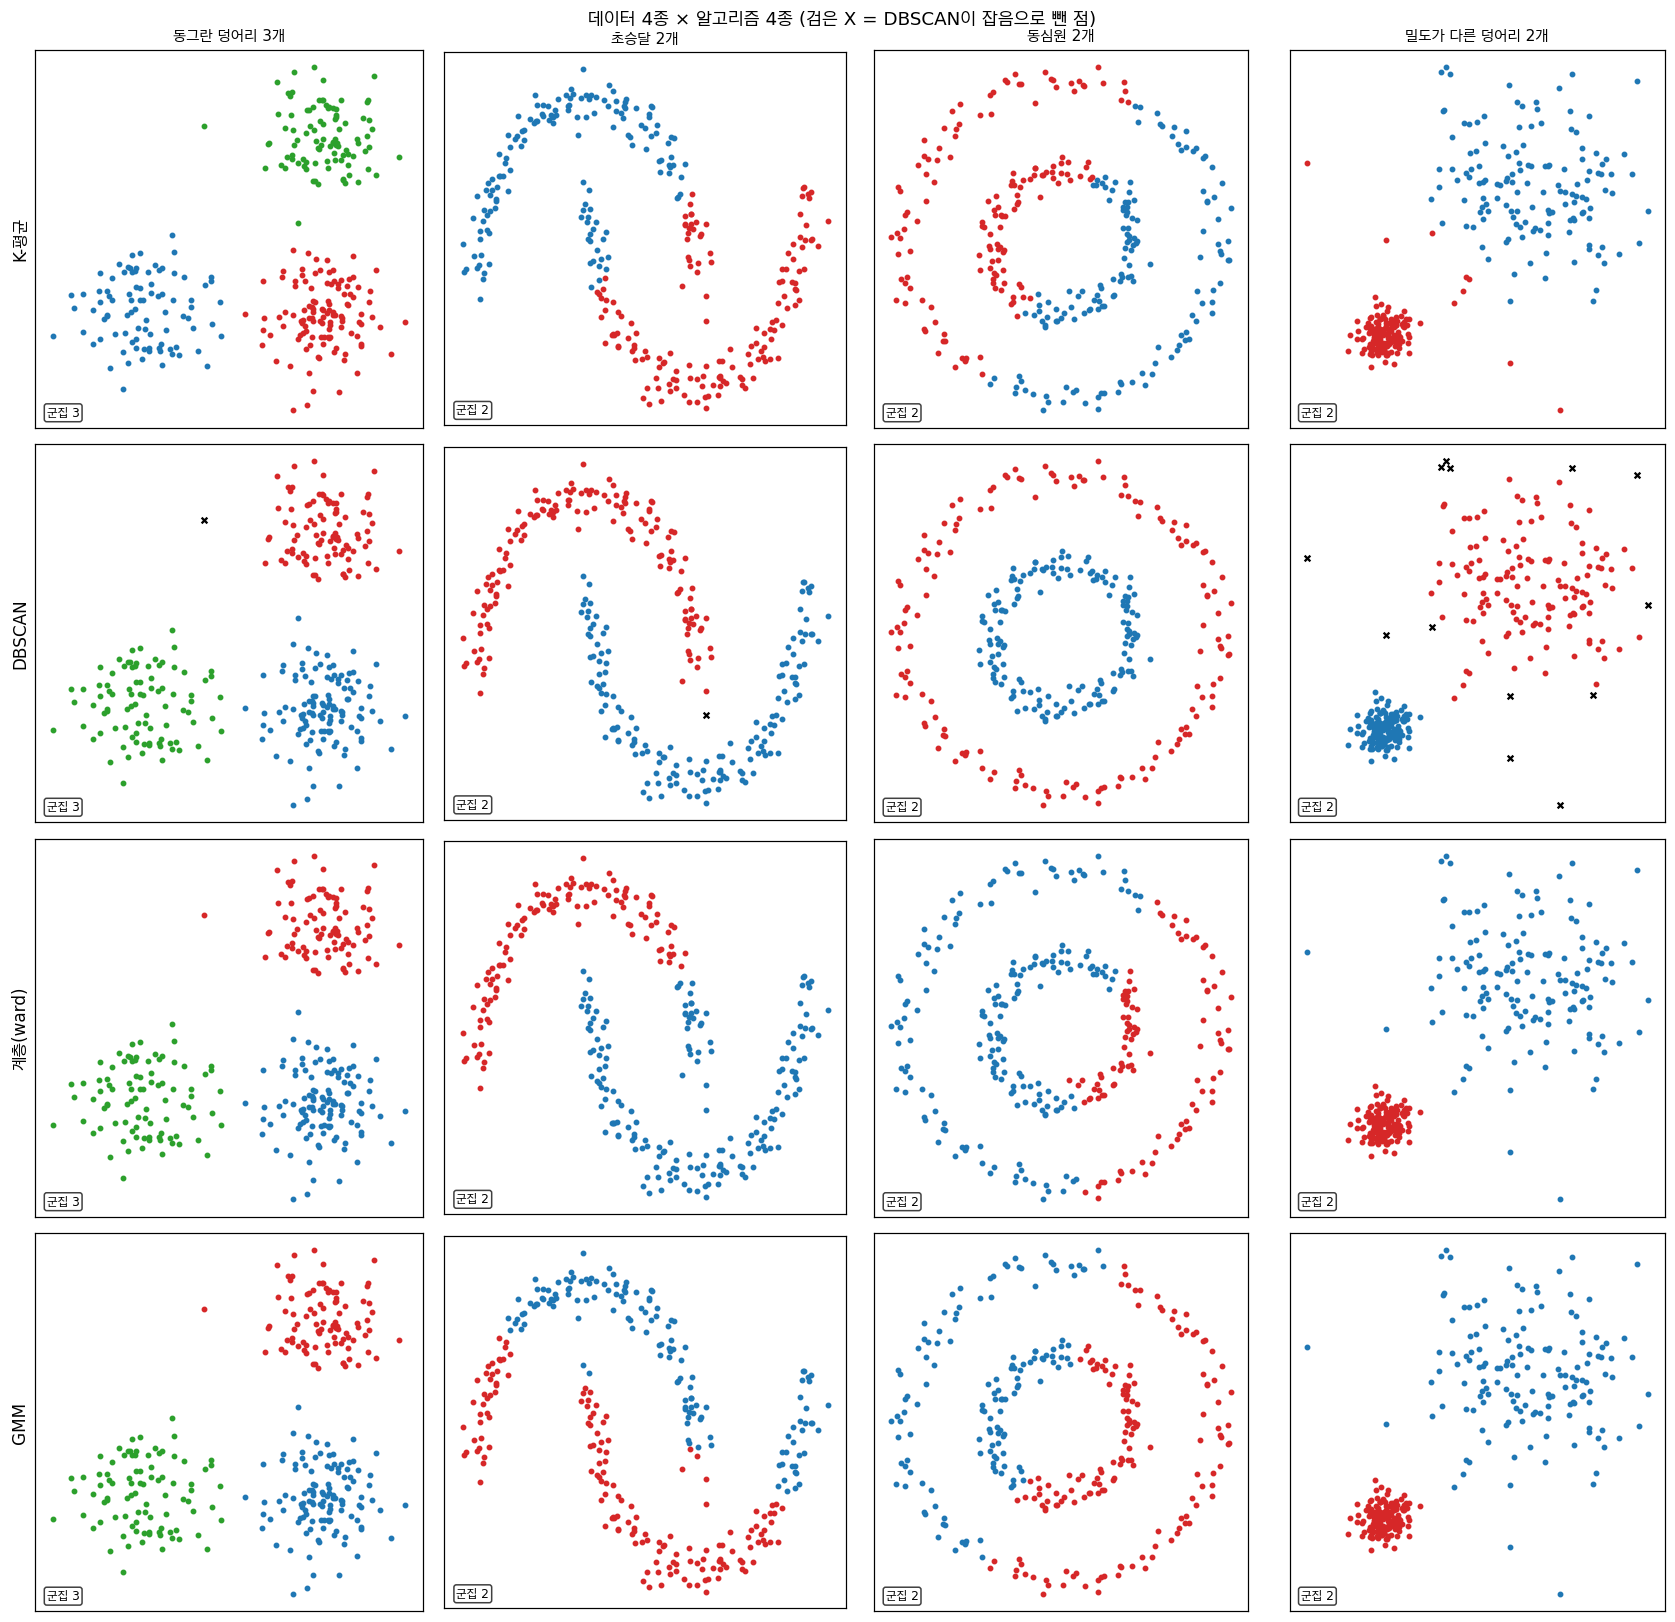

In [23]:
# ✨ 추가 — 데이터 4종 × 알고리즘 4종 한판 비교
from sklearn.cluster import AgglomerativeClustering

방법들 = [
    ("K-평균",   lambda X, K: K평균(K=K, 시드=0, 초기화="kmeans++").학습(X).배정),
    # ⚠️ eps는 표준화한 데이터 기준으로 미리 맞춰 둔 값입니다 (4절에서 봤듯 아주 예민합니다)
    ("DBSCAN",  lambda X, K: DBSCAN직접(X, eps=0.35, 최소이웃=5)[0]),
    ("계층(ward)", lambda X, K: AgglomerativeClustering(n_clusters=K).fit_predict(X)),
    ("GMM",     lambda X, K: GMM(K=K, 시드=0).학습(X).배정),
]

fig, ax = plt.subplots(len(방법들), len(데이터모음), figsize=(15.5, 15))
표결과 = {}
for j, (데이터이름, fn) in enumerate(데이터모음):
    Xd, 정답 = fn(0, 300)
    Xd = (Xd - Xd.mean(0)) / Xd.std(0)                # DBSCAN eps를 공통으로 쓰려면 표준화가 필수
    K개수 = len(np.unique(정답))
    for i, (방법이름, 함수) in enumerate(방법들):
        l = 함수(Xd, K개수)
        a_ = ax[i, j]
        for k in sorted(set(l) - {-1}):
            a_.scatter(Xd[l == k, 0], Xd[l == k, 1], s=8, c=색표[k % len(색표)])
        if -1 in l:
            a_.scatter(Xd[l == -1, 0], Xd[l == -1, 1], s=14, c="black", marker="x")
        군집수 = len(set(l) - {-1})
        점수 = 실루엣점수(Xd[l != -1], l[l != -1]) if 군집수 >= 2 else float("nan")
        표결과[(방법이름, 데이터이름)] = (군집수, 점수)
        a_.set_xticks([]); a_.set_yticks([]); a_.set_aspect("equal")
        if i == 0:
            a_.set_title(데이터이름, fontsize=10)
        if j == 0:
            a_.set_ylabel(방법이름, fontsize=11)
        a_.text(0.03, 0.03, f"군집 {군집수}", transform=a_.transAxes, fontsize=8,
                bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.75))
plt.suptitle("데이터 4종 × 알고리즘 4종 (검은 X = DBSCAN이 잡음으로 뺀 점)", fontsize=12)
plt.tight_layout(); plt.show()

In [24]:
# ✨ 추가 — 위 그림을 표로도 정리합니다
print(f"{'':<14}", end="")
for 이름, _ in 데이터모음:
    print(f"{이름[:9]:>12}", end="")
print()
print("-" * 62)
for 방법이름, _ in 방법들:
    print(f"{방법이름:<13}", end="")
    for 데이터이름, _ in 데이터모음:
        군집수, 점수 = 표결과[(방법이름, 데이터이름)]
        print(f"{f'{군집수}개/{점수:.2f}':>13}", end="")
    print()
print("\n(칸 안의 값 = 찾아낸 군집 수 / 실루엣 점수)")

print("\n=> 읽는 법")
print("   · K-평균·계층·GMM에는 정답 K를 넣어 줬습니다. 그러니 군집 수는 당연히 맞죠.")
print("     진짜로 볼 것은 '그림에서 색이 제대로 갈렸나'입니다.")
print("   · 초승달·동심원 줄을 보세요. K-평균·계층(ward)·GMM은 K가 맞는데도 색이 엉망입니다.")
print("     셋 다 '동그란 덩어리'를 전제하기 때문입니다.")
print("   · DBSCAN만 K를 안 받았는데도 네 데이터 모두 제대로 갈랐습니다.")

# 실루엣이 정말 DBSCAN을 낮게 평가하는지 직접 확인합니다
print("\n⚠️ 그런데 실루엣 점수를 보세요. 초승달·동심원에서 이런 일이 벌어집니다.")
for 데이터이름 in ["초승달 2개", "동심원 2개"]:
    km점 = 표결과[("K-평균", 데이터이름)][1]
    db점 = 표결과[("DBSCAN", 데이터이름)][1]
    이긴쪽 = "K-평균" if km점 > db점 else "DBSCAN"
    print(f"   {데이터이름}: K-평균 {km점:.2f} vs DBSCAN {db점:.2f}  -> 점수는 {이긴쪽}이 높음")
print("   그림으로는 DBSCAN이 명백히 옳은데 점수는 반대로 나옵니다.")
print("   실루엣이 '자기 군집 안에서 서로 가까운가'를 재는 지표라서 그렇습니다.")
print("   휜 모양은 같은 군집 안에서도 양 끝이 멀거든요.")
print("\n💡 교훈: 지표 하나만 믿으면 안 됩니다. 3절에서 만든 실루엣도 만능이 아닙니다.")
print("   비지도 학습에서는 '눈으로 보기'가 여전히 가장 중요한 평가 도구입니다.")

                 동그란 덩어리 3      초승달 2개      동심원 2개   밀도가 다른 덩어
--------------------------------------------------------------
K-평균               3개/0.67      2개/0.49      2개/0.34      2개/0.71
DBSCAN             3개/0.67      2개/0.38      2개/0.13      2개/0.74
계층(ward)           3개/0.67      2개/0.46      2개/0.31      2개/0.70
GMM                3개/0.67      2개/0.29      2개/0.34      2개/0.70

(칸 안의 값 = 찾아낸 군집 수 / 실루엣 점수)

=> 읽는 법
   · K-평균·계층·GMM에는 정답 K를 넣어 줬습니다. 그러니 군집 수는 당연히 맞죠.
     진짜로 볼 것은 '그림에서 색이 제대로 갈렸나'입니다.
   · 초승달·동심원 줄을 보세요. K-평균·계층(ward)·GMM은 K가 맞는데도 색이 엉망입니다.
     셋 다 '동그란 덩어리'를 전제하기 때문입니다.
   · DBSCAN만 K를 안 받았는데도 네 데이터 모두 제대로 갈랐습니다.

⚠️ 그런데 실루엣 점수를 보세요. 초승달·동심원에서 이런 일이 벌어집니다.
   초승달 2개: K-평균 0.49 vs DBSCAN 0.38  -> 점수는 K-평균이 높음
   동심원 2개: K-평균 0.34 vs DBSCAN 0.13  -> 점수는 K-평균이 높음
   그림으로는 DBSCAN이 명백히 옳은데 점수는 반대로 나옵니다.
   실루엣이 '자기 군집 안에서 서로 가까운가'를 재는 지표라서 그렇습니다.
   휜 모양은 같은 군집 안에서도 양 끝이 멀거든요.

💡 교훈: 지표 하나만 믿으면 안 됩니다. 3절에서 만든 실루엣도 만능이 아닙니다.
   비지도 학습에서는 '눈으로 보기'가 여전히 가장 중요한 평가 

> ✨ **추가** — 원문 저장소의 Ship It 가이드가 짚는 **두 가지**를 더 확인합니다.
> **① 데이터가 클 때는 뭘 쓰나 ② 실루엣 말고 다른 지표는 없나**

In [25]:
# ✨ 추가 — 데이터가 커지면 무엇을 써야 하나
from sklearn.cluster import MiniBatchKMeans
import time as _time

print(f"{'데이터 크기':>12}{'KMeans(초)':>13}{'MiniBatch(초)':>15}{'배율':>9}{'관성 차이':>12}")
print("-" * 63)
속도기록 = []
for n in [2000, 20000, 100000]:
    rr = np.random.default_rng(0)
    중심들 = np.array([[0.0, 0.0], [5.0, 5.0], [5.0, 0.0]])
    Xb = 중심들[rr.integers(0, 3, n)] + rr.normal(0, 0.9, size=(n, 2))

    t0 = _time.time(); km전체 = KMeans(n_clusters=3, n_init=10, random_state=0).fit(Xb)
    t1 = _time.time(); km미니 = MiniBatchKMeans(n_clusters=3, n_init=10,
                                                random_state=0).fit(Xb)
    t2 = _time.time()
    배율 = (t1 - t0) / max(t2 - t1, 1e-9)
    품질차 = (km미니.inertia_ - km전체.inertia_) / km전체.inertia_
    속도기록.append((n, 배율, 품질차))
    print(f"{n:>12}{t1-t0:>13.3f}{t2-t1:>15.3f}{배율:>8.1f}x{품질차:>+12.2%}")

작은것, 큰것 = 속도기록[0], 속도기록[-1]
최대품질차 = max(abs(r[2]) for r in 속도기록)
print("\n=> Mini-Batch K-평균은 매 반복에 전체가 아니라 **작은 묶음만** 씁니다.")
print(f"   '관성 차이' 열이 전부 {최대품질차:.2%} 안쪽입니다. 품질은 사실상 같다는 뜻이죠.")
print(f"   '배율' 열: {작은것[0]}개에서 {작은것[1]:.1f}배, {큰것[0]}개에서 {큰것[1]:.1f}배입니다.")
if 큰것[1] > 작은것[1]:
    print("   데이터가 클수록 이득이 커집니다.")
print("   ⚠️ 시간 측정은 실행할 때마다 흔들립니다. 이 표의 숫자를 그대로 믿지 마시고,")
print("      '데이터가 커지면 격차가 벌어진다'는 방향만 보세요.")
print("   ⚠️ 그리고 작은 데이터에서는 이득이 거의 없습니다. 묶음을 나누는 부대 비용이 있으니까요.")
print("   => **10만 개를 넘어갈 때부터 고민하면 됩니다.**")

print("\n📗 원문 가이드의 규모별 권장")
print("-" * 63)
for 크기, 권장 in [("1만 개 미만", "아무거나 됩니다"),
                  ("1만 ~ 100만", "K-평균 / Mini-Batch K-평균"),
                  ("100만 개 이상", "Mini-Batch K-평균 또는 BIRCH"),
                  ("2만 개 이상 + 계층적", "⚠️ 쓰지 마세요. O(n²) 메모리가 터집니다")]:
    print(f"  {크기:<22}{권장}")


      데이터 크기    KMeans(초)   MiniBatch(초)       배율       관성 차이
---------------------------------------------------------------
        2000        0.010          0.009     1.1x      +0.01%
       20000        0.725          0.215     3.4x      +0.02%
      100000        0.720          0.227     3.2x      +0.01%

=> Mini-Batch K-평균은 매 반복에 전체가 아니라 **작은 묶음만** 씁니다.
   '관성 차이' 열이 전부 0.02% 안쪽입니다. 품질은 사실상 같다는 뜻이죠.
   '배율' 열: 2000개에서 1.1배, 100000개에서 3.2배입니다.
   데이터가 클수록 이득이 커집니다.
   ⚠️ 시간 측정은 실행할 때마다 흔들립니다. 이 표의 숫자를 그대로 믿지 마시고,
      '데이터가 커지면 격차가 벌어진다'는 방향만 보세요.
   ⚠️ 그리고 작은 데이터에서는 이득이 거의 없습니다. 묶음을 나누는 부대 비용이 있으니까요.
   => **10만 개를 넘어갈 때부터 고민하면 됩니다.**

📗 원문 가이드의 규모별 권장
---------------------------------------------------------------
  1만 개 미만               아무거나 됩니다
  1만 ~ 100만             K-평균 / Mini-Batch K-평균
  100만 개 이상             Mini-Batch K-평균 또는 BIRCH
  2만 개 이상 + 계층적         ⚠️ 쓰지 마세요. O(n²) 메모리가 터집니다


In [26]:
# ✨ 추가 — 실루엣 말고 다른 지표들 (7절의 '지표를 맹신하지 말라'를 이어갑니다)
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score

print("같은 데이터에 K를 바꿔 가며 지표 네 개를 나란히 재 봅니다 (진짜 정답 K=3)\n")
print(f"{'K':>4}{'실루엣 ↑':>12}{'CH 지수 ↑':>13}{'DB 지수 ↓':>13}{'관성 ↓':>12}")
print("-" * 55)
지표기록 = []
for K in range(2, 9):
    m = K평균(K=K, 시드=0, 초기화="kmeans++").학습(X1)
    sil = 실루엣점수(X1, m.배정)
    ch = calinski_harabasz_score(X1, m.배정)
    db = davies_bouldin_score(X1, m.배정)
    지표기록.append((K, sil, ch, db, m.관성))
    print(f"{K:>4}{sil:>12.4f}{ch:>13.1f}{db:>13.4f}{m.관성:>12.1f}")

고른것 = {"실루엣 (최대)": max(지표기록, key=lambda r: r[1])[0],
          "CH 지수 (최대)": max(지표기록, key=lambda r: r[2])[0],
          "DB 지수 (최소)": min(지표기록, key=lambda r: r[3])[0]}
print("\n각 지표가 고른 K")
for 이름, K in 고른것.items():
    print(f"   {이름:<16} K = {K}   {'맞음' if K == 3 else '틀림'}")

맞춘개수 = sum(1 for K in 고른것.values() if K == 3)
print(f"\n=> 지표 {len(고른것)}개 중 {맞춘개수}개가 정답 K=3을 골랐습니다.")
print("   ↑ 는 '클수록 좋음', ↓ 는 '작을수록 좋음'입니다. 방향을 꼭 확인하세요.")
print("\n   · CH 지수 (Calinski-Harabasz): 군집 사이 분산 ÷ 군집 안 분산. 계산이 빨라 빠른 비교에 좋습니다")
print("   · DB 지수 (Davies-Bouldin): 군집끼리 얼마나 닮았나(겹치나). 겹치면 벌점입니다")
print("\n💡 ⚠️ 셋 다 '동그란 군집'을 좋아하는 지표입니다. 7절에서 본 실루엣의 약점을 그대로 공유합니다.")
print("   즉 지표를 여러 개 봐도 초승달·동심원에서는 **다 같이 틀릴 수 있습니다.**")
print("   **지표를 늘리는 것보다 그림을 보는 게 확실합니다.**")

같은 데이터에 K를 바꿔 가며 지표 네 개를 나란히 재 봅니다 (진짜 정답 K=3)

   K       실루엣 ↑      CH 지수 ↑      DB 지수 ↓        관성 ↓
-------------------------------------------------------
   2      0.5125        316.1       0.7273      1788.5
   3      0.6727       1008.6       0.4442       473.0
   4      0.5710        776.4       0.8315       415.6
   5      0.5627        654.9       0.7028       373.0
   6      0.4409        632.5       0.8811       313.5
   7      0.4491        576.4       0.8344       287.9
   8      0.4428        549.1       0.8376       260.2

각 지표가 고른 K
   실루엣 (최대)         K = 3   맞음
   CH 지수 (최대)       K = 3   맞음
   DB 지수 (최소)       K = 3   맞음

=> 지표 3개 중 3개가 정답 K=3을 골랐습니다.
   ↑ 는 '클수록 좋음', ↓ 는 '작을수록 좋음'입니다. 방향을 꼭 확인하세요.

   · CH 지수 (Calinski-Harabasz): 군집 사이 분산 ÷ 군집 안 분산. 계산이 빨라 빠른 비교에 좋습니다
   · DB 지수 (Davies-Bouldin): 군집끼리 얼마나 닮았나(겹치나). 겹치면 벌점입니다

💡 ⚠️ 셋 다 '동그란 군집'을 좋아하는 지표입니다. 7절에서 본 실루엣의 약점을 그대로 공유합니다.
   즉 지표를 여러 개 봐도 초승달·동심원에서는 **다 같이 틀릴 수 있습니다.**
   **지표를 늘리는 것보다 그림을 보는 게 확실합니다.**


In [27]:
# ✨ 추가 — 위 주장을 확인합니다: 휜 모양에서는 세 지표가 '다 같이' 틀립니다
print("같은 데이터에 K-평균(그림상 틀림)과 DBSCAN(그림상 맞음)을 붙이고,")
print("세 지표가 어느 쪽을 더 좋게 평가하는지 봅니다.\n")

for 데이터이름, fn in [("초승달 2개", 초승달), ("동심원 2개", 동심원)]:
    Xn, _ = fn(0, 300)
    Xn = (Xn - Xn.mean(0)) / Xn.std(0)          # 4절에서 본 대로 eps를 쓰려면 표준화 필요
    km배정 = KMeans(n_clusters=2, n_init=10, random_state=0).fit_predict(Xn)
    db배정, _ = DBSCAN직접(Xn, eps=0.35, 최소이웃=5)
    유효 = db배정 != -1

    print(f"[{데이터이름}]  DBSCAN이 찾은 군집 {len(set(db배정[유효]))}개, "
          f"잡음 {int((~유효).sum())}개")
    print(f"   {'지표':<10}{'K-평균':>11}{'DBSCAN':>11}   점수가 고르는 쪽")
    print("   " + "-" * 50)
    for 지표이름, 함수, 방향 in [("실루엣 ↑", 실루엣점수, "max"),
                                ("CH 지수 ↑", calinski_harabasz_score, "max"),
                                ("DB 지수 ↓", davies_bouldin_score, "min")]:
        a = 함수(Xn, km배정)
        b = 함수(Xn[유효], db배정[유효])
        이긴쪽 = ("K-평균" if a > b else "DBSCAN") if 방향 == "max" else \
                 ("K-평균" if a < b else "DBSCAN")
        표시 = "  ⚠️ 그림과 반대!" if 이긴쪽 == "K-평균" else "  ✔ 그림과 일치"
        print(f"   {지표이름:<10}{a:>11.3f}{b:>11.3f}   {이긴쪽}{표시}")
    print()

print("=> **세 지표가 전부 K-평균을 골랐습니다.** 그림으로는 DBSCAN이 명백히 맞는데도요.")
print("   동심원의 CH 지수를 보세요. K-평균 167.9 vs DBSCAN 0.018 — 1만 배 차이입니다.")
print("   DBSCAN이 찾은 '고리' 모양 군집은 군집 안 분산이 크니까요. 지표가 그걸 벌점으로 봅니다.")
print("\n💡 그래서 이렇게 정리해야 맞습니다.")
print("   · 지표는 **같은 알고리즘 안에서 K를 비교할 때** 믿을 만합니다 (K-평균의 K=2 vs 3 vs 4)")
print("   · **서로 다른 알고리즘을 비교할 때는 못 믿습니다.** 전제가 다르니까요")
print("   · 지표를 여러 개 봐도 소용없습니다. 셋 다 '동그란 군집'을 좋아하는 같은 편이거든요")
print("   · ⚠️ 결국 **그림을 보고 도메인 지식으로 판단**해야 합니다. 10절 흔한 실수 5번이 이 이야기입니다")

같은 데이터에 K-평균(그림상 틀림)과 DBSCAN(그림상 맞음)을 붙이고,
세 지표가 어느 쪽을 더 좋게 평가하는지 봅니다.

[초승달 2개]  DBSCAN이 찾은 군집 2개, 잡음 1개
   지표               K-평균     DBSCAN   점수가 고르는 쪽
   --------------------------------------------------
   실루엣 ↑           0.492      0.383   K-평균  ⚠️ 그림과 반대!
   CH 지수 ↑       412.651    255.704   K-평균  ⚠️ 그림과 반대!
   DB 지수 ↓         0.810      1.026   K-평균  ⚠️ 그림과 반대!

[동심원 2개]  DBSCAN이 찾은 군집 2개, 잡음 0개
   지표               K-평균     DBSCAN   점수가 고르는 쪽
   --------------------------------------------------
   실루엣 ↑           0.343      0.131   K-평균  ⚠️ 그림과 반대!
   CH 지수 ↑       167.901      0.018   K-평균  ⚠️ 그림과 반대!
   DB 지수 ↓         1.188    119.350   K-평균  ⚠️ 그림과 반대!

=> **세 지표가 전부 K-평균을 골랐습니다.** 그림으로는 DBSCAN이 명백히 맞는데도요.
   동심원의 CH 지수를 보세요. K-평균 167.9 vs DBSCAN 0.018 — 1만 배 차이입니다.
   DBSCAN이 찾은 '고리' 모양 군집은 군집 안 분산이 크니까요. 지표가 그걸 벌점으로 봅니다.

💡 그래서 이렇게 정리해야 맞습니다.
   · 지표는 **같은 알고리즘 안에서 K를 비교할 때** 믿을 만합니다 (K-평균의 K=2 vs 3 vs 4)
   · **서로 다른 알고리즘을 비교할 때는 못 믿습니다.** 전제가 다르니까요
   · 지표를 여러 개 봐도 소용

---

## 8️⃣ 군집화로 이상 탐지

> 📗 **원문** — "Anomaly Detection with Clustering"
>
> 🔗 **앞 절과 이어서** — 군집화를 하면 **덤으로 따라오는 게** 있습니다.
> **"어느 무리에도 안 어울리는 점"**이 눈에 띄거든요. 그게 이상치입니다.

### 📗 세 알고리즘이 각자 다른 방식으로 잡습니다

| 방법 | 이상치를 어떻게 정의하나 |
| --- | --- |
| **K-평균** | **어느 중심에서도 먼** 점 |
| **DBSCAN** | **잡음점**. 정의상 이미 이상치입니다 (추가 작업 0) |
| **GMM** | 모든 정규분포 아래에서 **확률이 낮은** 점 |

### 🧸 비유 — 반 배정 후 남는 아이

- **K-평균**: "어느 모둠 자리에서도 멀리 떨어져 앉은 아이"
- **DBSCAN**: "애초에 어느 모둠에도 안 들어간 아이"
- **GMM**: "어느 모둠에 넣어 봐도 어울릴 확률이 낮은 아이"

세 방법이 **같은 점을 잡을 수도, 다른 점을 잡을 수도** 있습니다.
원문 연습문제 3번이 바로 **"셋이 동의하는 점만 이상치로 보자"**입니다. 아래에서 풀어 봅니다.

In [28]:
# ✨ 추가 — 원문 연습문제 3번: 세 방법을 겹쳐 이상치를 잡습니다
r = np.random.default_rng(0)
정상, _ = 덩어리(0, 300)
심어둔이상치 = np.array([[12.0, 12.0], [-6.0, -6.0], [10.0, -5.0],
                        [2.5, 2.5], [-4.0, 6.0]])       # 우리가 일부러 넣은 점 5개
X이상 = np.vstack([정상, 심어둔이상치])
이상치정답 = np.array([False]*len(정상) + [True]*len(심어둔이상치))

# ① K-평균: 중심까지 거리가 상위 2%
km이 = K평균(K=3, 시드=0, 초기화="kmeans++").학습(X이상)
중심거리 = np.linalg.norm(X이상 - km이.중심[km이.배정], axis=1)
km이상 = 중심거리 > np.percentile(중심거리, 98)

# ② DBSCAN: 잡음점 그대로
db라벨, _ = DBSCAN직접(X이상, eps=1.0, 최소이웃=5)
db이상 = db라벨 == -1

# ③ GMM: 확률밀도가 하위 2%
gm이 = GMM(K=3, 시드=0).학습(X이상)
밀도 = np.array([gm이.비중[k] * gm이._정규분포밀도(X이상, gm이.평균[k], gm이.공분산[k])
                for k in range(3)]).sum(axis=0)
gm이상 = 밀도 < np.percentile(밀도, 2)

print(f"{'방법':<12}{'잡아낸 점':>10}{'심어둔 5개 중':>14}{'헛짚음':>10}")
print("-" * 48)
for 이름, 결과 in [("K-평균", km이상), ("DBSCAN", db이상), ("GMM", gm이상)]:
    맞춤 = int((결과 & 이상치정답).sum())
    헛짚음 = int((결과 & ~이상치정답).sum())
    print(f"{이름:<11}{int(결과.sum()):>10}{f'{맞춤}개':>14}{헛짚음:>10}")

셋다 = km이상 & db이상 & gm이상
둘이상 = (km이상.astype(int) + db이상.astype(int) + gm이상.astype(int)) >= 2
print(f"\n세 방법이 모두 동의  : {int(셋다.sum())}개  "
      f"(심어둔 것 {int((셋다 & 이상치정답).sum())}개, 헛짚음 {int((셋다 & ~이상치정답).sum())}개)")
print(f"둘 이상이 동의      : {int(둘이상.sum())}개  "
      f"(심어둔 것 {int((둘이상 & 이상치정답).sum())}개, 헛짚음 {int((둘이상 & ~이상치정답).sum())}개)")
print("\n=> 여러 방법을 겹치면 헛짚음이 줄어듭니다. 대신 놓치는 것도 늘어나죠.")
print("   3단원에서 배운 정밀도-재현율 맞바꿈이 여기서도 그대로 나타납니다.")

방법               잡아낸 점      심어둔 5개 중       헛짚음
------------------------------------------------
K-평균                7            5개         2
DBSCAN              6            5개         1
GMM                 7            4개         3

세 방법이 모두 동의  : 5개  (심어둔 것 4개, 헛짚음 1개)
둘 이상이 동의      : 6개  (심어둔 것 5개, 헛짚음 1개)

=> 여러 방법을 겹치면 헛짚음이 줄어듭니다. 대신 놓치는 것도 늘어나죠.
   3단원에서 배운 정밀도-재현율 맞바꿈이 여기서도 그대로 나타납니다.


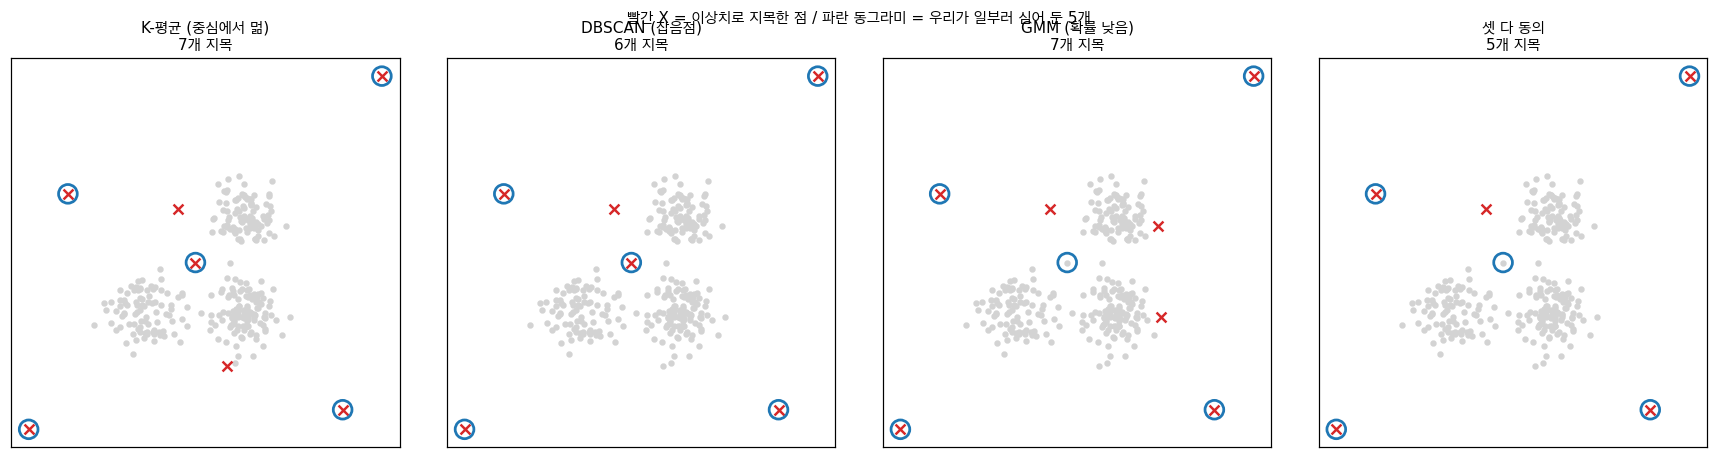

          심어 둔 점     K-평균   DBSCAN    GMM   위치
--------------------------------------------------------------
       [12. 12.]        O        O      O   바깥쪽 멀리
       [-6. -6.]        O        O      O   바깥쪽 멀리
       [10. -5.]        O        O      O   바깥쪽 멀리
       [2.5 2.5]        O        O      -   군집 사이 한가운데
       [-4.  6.]        O        O      O   바깥쪽 멀리

=> 바깥쪽 멀리 있는 점은 세 방법이 다 잡습니다. 쉬운 문제죠.
   갈리는 건 '군집 사이 한가운데'인 [2.5 2.5] 입니다.
   잡은 쪽: K-평균, DBSCAN   /   놓친 쪽: GMM

   GMM이 이 점에 준 확률밀도는 전체에서 아래에서 9번째입니다 (하위 3.0%).
   하위 2%가 기준이었으니 기준을 살짝 넘겨 빠져나갔습니다.
   GMM이 찾은 정규분포들의 꼬리가 넓어서, 이 자리도 '나올 법한 곳'으로 본 겁니다.

💡 정리하면 — 이상치라고 다 같은 이상치가 아닙니다.
   · K-평균  = '중심에서 먼가'로 봅니다. 바깥으로 튄 점에 강합니다.
   · DBSCAN = '이웃이 있나'로 봅니다. 텅 빈 자리에 있는 점에 강합니다.
             군집 사이 빈 공간도 '텅 빈 자리'라서 이번엔 이게 잘 통했습니다.
   · GMM    = '분포에서 나올 확률'로 봅니다. 정규분포 가정이 맞을 때 강합니다.
             대신 꼬리가 넓게 잡히면 어중간한 점을 놓칩니다. 이번이 그 경우였죠.
   기준이 서로 다르니 결과도 다릅니다. 그래서 실무에서는 겹쳐서 씁니다.


In [29]:
# ✨ 추가 — 어느 점을 누가 잡았는지 그림으로
fig, ax = plt.subplots(1, 4, figsize=(16, 4.2))
for a_, (이름, 결과) in zip(ax, [("K-평균 (중심에서 멂)", km이상), ("DBSCAN (잡음점)", db이상),
                                ("GMM (확률 낮음)", gm이상), ("셋 다 동의", 셋다)]):
    a_.scatter(X이상[~결과, 0], X이상[~결과, 1], s=10, c="lightgray")
    a_.scatter(X이상[결과, 0], X이상[결과, 1], s=42, c="tab:red", marker="x", linewidths=1.6)
    a_.scatter(심어둔이상치[:, 0], 심어둔이상치[:, 1], s=150, facecolors="none",
               edgecolors="tab:blue", linewidths=1.8)
    a_.set_title(f"{이름}\n{int(결과.sum())}개 지목", fontsize=10)
    a_.set_aspect("equal"); a_.set_xticks([]); a_.set_yticks([])
plt.suptitle("빨간 X = 이상치로 지목한 점 / 파란 동그라미 = 우리가 일부러 심어 둔 5개", fontsize=10)
plt.tight_layout(); plt.show()

# 심어 둔 5개를 누가 잡았는지 하나씩 확인합니다
심은자리 = np.arange(len(정상), len(X이상))
print(f"{'심어 둔 점':>16}{'K-평균':>9}{'DBSCAN':>9}{'GMM':>7}   위치")
print("-" * 62)
for 번호, 자리 in enumerate(심은자리):
    p = X이상[자리]
    설명 = "군집 사이 한가운데" if abs(p[0] - 2.5) < 0.1 and abs(p[1] - 2.5) < 0.1 else "바깥쪽 멀리"
    print(f"{str(np.round(p,1)):>16}"
          f"{('O' if km이상[자리] else '-'):>9}{('O' if db이상[자리] else '-'):>9}"
          f"{('O' if gm이상[자리] else '-'):>7}   {설명}")

가운데자리 = 심은자리[3]
잡은쪽 = [이름 for 이름, 결과 in [("K-평균", km이상), ("DBSCAN", db이상), ("GMM", gm이상)]
          if 결과[가운데자리]]
놓친쪽 = [이름 for 이름, 결과 in [("K-평균", km이상), ("DBSCAN", db이상), ("GMM", gm이상)]
          if not 결과[가운데자리]]

print("\n=> 바깥쪽 멀리 있는 점은 세 방법이 다 잡습니다. 쉬운 문제죠.")
print(f"   갈리는 건 '군집 사이 한가운데'인 {np.round(X이상[가운데자리],1)} 입니다.")
print(f"   잡은 쪽: {', '.join(잡은쪽)}   /   놓친 쪽: {', '.join(놓친쪽)}")

# GMM이 이 점을 어떻게 봤는지 들여다봅니다
순위 = int((밀도 < 밀도[가운데자리]).sum())
print(f"\n   GMM이 이 점에 준 확률밀도는 전체에서 아래에서 {순위+1}번째입니다"
      f" (하위 {(순위+1)/len(X이상):.1%}).")
print(f"   하위 2%가 기준이었으니 {'턱걸이로 걸렸습니다' if (순위+1)/len(X이상) <= 0.02 else '기준을 살짝 넘겨 빠져나갔습니다'}.")
print("   GMM이 찾은 정규분포들의 꼬리가 넓어서, 이 자리도 '나올 법한 곳'으로 본 겁니다.")

print("\n💡 정리하면 — 이상치라고 다 같은 이상치가 아닙니다.")
print("   · K-평균  = '중심에서 먼가'로 봅니다. 바깥으로 튄 점에 강합니다.")
print("   · DBSCAN = '이웃이 있나'로 봅니다. 텅 빈 자리에 있는 점에 강합니다.")
print("             군집 사이 빈 공간도 '텅 빈 자리'라서 이번엔 이게 잘 통했습니다.")
print("   · GMM    = '분포에서 나올 확률'로 봅니다. 정규분포 가정이 맞을 때 강합니다.")
print("             대신 꼬리가 넓게 잡히면 어중간한 점을 놓칩니다. 이번이 그 경우였죠.")
print("   기준이 서로 다르니 결과도 다릅니다. 그래서 실무에서는 겹쳐서 씁니다.")

---

## 9️⃣ 실무 — sklearn

> 🔗 **앞 절과 이어서** — 여기까지 네 알고리즘을 전부 직접 만들었습니다.
> 실무에서는 라이브러리를 씁니다. 다만 **직접 만들어 봤기 때문에**
> `eps`가 왜 예민한지, `n_init`이 왜 필요한지 알고 쓸 수 있습니다.

> 📗 **원문** — "Use It"

```python
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture

km  = KMeans(n_clusters=3, random_state=42).fit(data)
db  = DBSCAN(eps=1.5, min_samples=5).fit(data)
agg = AgglomerativeClustering(n_clusters=3).fit(data)
gmm = GaussianMixture(n_components=3, random_state=42).fit(data)
```

> 📗 원문: "The from-scratch versions show you exactly what these libraries compute. …
> The library versions add numerical stability, smarter initialization (K-Means++),
> and GPU acceleration, but the core logic is the same."

### ⚠️ 실무 체크리스트

1. **거리를 쓰는 방법은 전부 스케일링이 필요합니다.** (K-평균, DBSCAN, 계층적)
   6단원 KNN, 5단원 SVM과 똑같은 이유입니다.
2. **K-평균은 `n_init`을 1보다 크게.** 시작점 운에 좌우되니까요 (1절에서 봤죠).
3. **DBSCAN의 eps는 반드시 데이터를 보고 정하세요.** k-거리 그래프를 그리는 게 표준 방법입니다.
4. **차원이 높으면 먼저 줄이세요.** PCA로 줄이고 나서 군집화합니다 (6단원 차원의 저주와 같은 이유).

In [30]:
# 📗 원문 Use It — 네 줄이면 끝입니다
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

데이터 = X1
km = KMeans(n_clusters=3, n_init=10, random_state=42).fit(데이터)
# ⚠️ 원문 예제는 eps=1.5인데, 그건 원문 데이터 기준입니다.
#    우리 데이터에는 너무 커서 전부 한 덩어리가 됩니다. 아래 셀의 k-거리 그래프로 정한 값을 씁니다
db = DBSCAN(eps=0.8, min_samples=5).fit(데이터)
agg = AgglomerativeClustering(n_clusters=3).fit(데이터)
gmm = GaussianMixture(n_components=3, random_state=42).fit(데이터)

print(f"{'모델':<24}{'군집 수':>9}{'실루엣':>10}")
print("-" * 45)
for 이름, 라벨 in [("KMeans", km.labels_), ("DBSCAN", db.labels_),
                  ("AgglomerativeClustering", agg.labels_), ("GaussianMixture", gmm.predict(데이터))]:
    유효 = 라벨 != -1
    수 = len(set(라벨[유효]))
    점 = silhouette_score(데이터[유효], 라벨[유효]) if 수 >= 2 else float("nan")
    print(f"{이름:<24}{수:>9}{점:>10.4f}")

모델                           군집 수       실루엣
---------------------------------------------
KMeans                          3    0.6727
DBSCAN                          3    0.6765
AgglomerativeClustering         3    0.6723
GaussianMixture                 3    0.6723


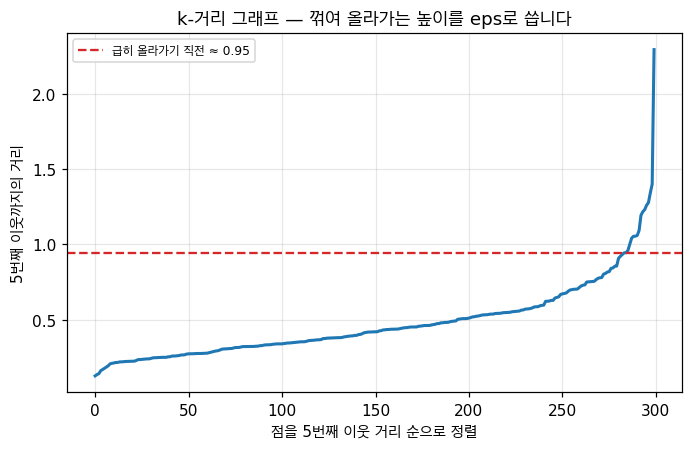

이 그래프가 제안하는 eps ≈ 0.946

     eps     군집 수     잡음 점
----------------------------
    0.47        3       62
    0.76        3        8
    0.95        2        1
    1.42        1        1
    2.36        1        0

=> 그래프가 급히 올라가는 지점 = '이 거리를 넘으면 이웃이 아니다' 하는 경계입니다.
   대부분의 점은 그 아래에 이웃이 있고, 그 위로 튀는 점들이 잡음 후보입니다.


In [31]:
# ✨ 추가 — DBSCAN의 eps를 정하는 표준 방법: k-거리 그래프
def k거리그래프(X, k=5):
    D = np.sqrt(((X[:, None, :] - X[None]) ** 2).sum(-1))
    # 자기 자신(0)을 빼고 k번째로 가까운 이웃까지의 거리
    return np.sort(np.sort(D, axis=1)[:, k])

거리 = k거리그래프(X1, k=5)
꺾임 = float(np.percentile(거리, 95))

plt.figure(figsize=(6.4, 4.2))
plt.plot(거리, lw=2)
plt.axhline(꺾임, c="tab:red", ls="--", lw=1.5, label=f"급히 올라가기 직전 ≈ {꺾임:.2f}")
plt.xlabel("점을 5번째 이웃 거리 순으로 정렬"); plt.ylabel("5번째 이웃까지의 거리")
plt.title("k-거리 그래프 — 꺾여 올라가는 높이를 eps로 씁니다")
plt.legend(fontsize=8); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"이 그래프가 제안하는 eps ≈ {꺾임:.3f}\n")
print(f"{'eps':>8}{'군집 수':>9}{'잡음 점':>9}")
print("-" * 28)
for e in [꺾임 * 0.5, 꺾임 * 0.8, 꺾임, 꺾임 * 1.5, 꺾임 * 2.5]:
    l = DBSCAN(eps=e, min_samples=5).fit_predict(X1)
    print(f"{e:>8.2f}{len(set(l) - {-1}):>9}{int((l == -1).sum()):>9}")

print("\n=> 그래프가 급히 올라가는 지점 = '이 거리를 넘으면 이웃이 아니다' 하는 경계입니다.")
print("   대부분의 점은 그 아래에 이웃이 있고, 그 위로 튀는 점들이 잡음 후보입니다.")

---

## 🔟 🎒 Ship It — 군집화 알고리즘 선택 가이드

> 📗 **원문** — 저장소의 `phases/02-ml-fundamentals/07-unsupervised-learning/outputs/skill-clustering-guide.md`
> 원문 파일을 우리말로 옮기고, **이 노트북에서 확인한 절 번호를 붙였습니다.**
>
> 🔗 **이 절은 요약이 아니라 '판단 도구'입니다** — 0~9절이 "각 알고리즘이 무엇인가"였다면,
> 여기는 **"내 데이터에는 뭘 써야 하나"**에 답하는 체크리스트입니다.
> 실무에서 꺼내 쓰는 부분이 바로 여기예요.

### 📗 결정 체크리스트 — 다섯 가지를 순서대로 물어보세요

**① 군집 개수를 아는가?**

| 답 | 쓸 것 |
| --- | --- |
| 예 | **K-평균** 또는 **GMM** |
| 아니오 | **DBSCAN** (자동으로 찾음) 또는 **계층적** (덴드로그램을 여러 높이에서 잘라 보기) |

**② 군집 모양이 어떤가?**

| 모양 | 쓸 것 | 이 노트북 |
| --- | --- | --- |
| 대충 동그란 덩어리 | **K-평균** | 1절 |
| 크기가 다른 **타원** | **GMM** | 6절 — 일치도 89% → 100% |
| **아무 모양** (초승달·고리·사슬) | **DBSCAN** | 4절 |
| 겹겹이 든 구조 | **계층적** | 5절 |

**③ 잡음이나 이상치가 있는가?**

| 답 | 쓸 것 | 이 노트북 |
| --- | --- | --- |
| 예 | **DBSCAN** (잡음점을 명시적으로 표시) 또는 **GMM** (확률 낮은 점) | 8절 |
| 아니오 | K-평균으로 충분합니다 | — |

**④ 부드러운 배정(확률)이 필요한가?**

| 답 | 쓸 것 | 이 노트북 |
| --- | --- | --- |
| 예 | **GMM** — 점마다 "1번 70%, 2번 30%" 를 줍니다 | 6절 |
| 아니오 | K-평균, DBSCAN (딱 잘라 배정) | 1·4절 |

**⑤ 데이터가 얼마나 큰가?**

| 크기 | 쓸 것 | 이 노트북 |
| --- | --- | --- |
| 1만 개 미만 | 아무거나 | — |
| 1만 ~ 100만 | **K-평균**, **Mini-Batch K-평균** | 7절 (속도 측정) |
| 100만 개 이상 | **Mini-Batch K-평균** 또는 **BIRCH** | 7절 |
| — | ⚠️ **계층적은 2만 개가 넘으면 쓰지 마세요.** $O(n^2)$ 메모리 | 5절 |

---

### 📗 빠른 참조표

| 알고리즘 | 군집 모양 | K를 찾나 | 잡음 처리 | 부드러운 배정 | 확장성 |
| --- | --- | --- | --- | --- | --- |
| **K-평균** | 동그란 | ❌ 내가 정함 | ❌ | ❌ | 수백만 |
| **Mini-Batch K-평균** | 동그란 | ❌ | ❌ | ❌ | 수천만 |
| **DBSCAN** | 아무 모양 | ✅ | ✅ | ❌ | 수십만 |
| **계층적** | 연결 방식에 따라 | ✅ 유연 (자르기) | 연결 방식에 따라 | ❌ | 2만 미만 |
| **GMM** | 타원 | ❌ | 부분적 (확률 낮음) | ✅ | 10만 미만 |
| **HDBSCAN** | 아무 모양 | ✅ | ✅ | 부분적 | 수십만 |

---

### 📗 라벨이 없을 때 품질 재는 법

| 지표 | 재는 것 | 방향 | 쓸 때 | 이 노트북 |
| --- | --- | --- | --- | --- |
| **실루엣** | 응집도 대 분리도 | −1 ~ 1, 클수록 ↑ | K나 알고리즘 비교 | 3절 (직접 구현) |
| **관성** | 군집이 얼마나 뭉쳤나 | 작을수록 ↑ | K-평균 엘보 | 1·3절 |
| **BIC / AIC** | 우도 − 복잡도 벌점 | 작을수록 ↑ | **GMM 성분 수** | 6절 |
| **CH 지수** | 군집 간 분산 ÷ 군집 내 분산 | 클수록 ↑ | 빠른 비교 | 7절 |
| **DB 지수** | 군집끼리 얼마나 겹치나 | 작을수록 ↑ | 겹침에 벌점 | 7절 |

---

### ⚠️ 📗 흔한 실수 여섯 가지

| # | 실수 | 왜 나쁜가 | 이 노트북 |
| --- | --- | --- | --- |
| 1 | **스케일링 없이 K-평균** | 숫자가 큰 특징이 거리를 지배합니다 | 9절 체크리스트 |
| 2 | 2차원 그림만 보고 K를 정하기 | 실제 데이터는 고차원입니다. 실루엣을 쓰세요 | 3절 |
| 3 | **동그랗지 않은 군집에 K-평균** | 초승달·고리는 DBSCAN이 필요합니다 | 2·4·7절 |
| 4 | DBSCAN `eps`를 너무 크게/작게 | 크면 한 덩어리, 작으면 전부 잡음 | 4절 (표로 확인) |
| 5 | **군집 라벨을 정답처럼 취급** | 군집화는 **탐색**입니다. 도메인 지식으로 검증해야 합니다 | — |
| 6 | 2만 개 넘는 데이터에 계층적 | 메모리와 시간이 폭발합니다 | 5절 |

> 🔑 **5번이 가장 많이 하는 실수입니다.** 군집 3개가 나왔다고 "고객 유형이 3가지"인 게 아닙니다.
> **"이 데이터를 3개로 나누면 이렇게 갈린다"**일 뿐이에요. 정답이 없는 게 비지도 학습입니다.

---

## 1️⃣1️⃣ 📝 자가 점검 퀴즈

> 📗 **원문** — 저장소의 `phases/02-ml-fundamentals/07-unsupervised-learning/quiz.json`
> 우리말로 옮기고, 각 문항이 이 노트북 **몇 절**에 있는지 표시했습니다.
>
> 💡 클론한 저장소가 있으면 Claude Code에서 `/check-understanding 2` 로도 풀 수 있습니다.

**먼저 답을 정한 뒤에** 아래 코드 셀을 실행해 정답을 확인하세요.

### 사전 점검 — 배우기 전에 알았어야 하는 것

**1. 비지도 학습이 지도 학습과 다른 점은?**

1. 비지도 학습이 항상 결과가 더 좋다
2. 비지도 학습은 데이터를 더 많이 쓴다
3. 라벨(정답)이 없다 — 알고리즘이 스스로 구조를 찾는다
4. 비지도 학습은 텍스트 데이터에만 쓸 수 있다

**2. K-평균이 학습 전에 반드시 지정해야 하는 것은?**

1. 각 군집의 정확한 중심
2. 군집 개수 K
3. 쓸 거리 함수
4. 각 점의 라벨

### 사후 점검 — 이 단원을 배운 뒤에 알아야 하는 것

**3. 맞물린 초승달 두 개에서 K-평균은 실패하고 DBSCAN은 성공합니다. 왜?**

1. DBSCAN이 모든 데이터에서 K-평균보다 낫다
2. DBSCAN이 데이터를 더 많이 쓴다
3. DBSCAN은 밀도로 군집을 찾으니 아무 모양이나 찾을 수 있고, K-평균은 동그란 모양을 전제한다
4. K-평균은 2차원 데이터를 다룰 수 없다

**4. 실루엣 점수가 재는 것은?**

1. 찾아낸 군집의 총 개수
2. 각 점이 자기 군집과 얼마나 비슷한지를, 가장 가까운 다른 군집과 비교한 값
3. 군집화 알고리즘의 속도
4. 데이터에 이상치가 몇 %인지

**5. GMM의 군집 배정이 K-평균과 다른 점은?**

1. GMM은 각 점이 정확히 한 군집에 속하는 하드 배정을 쓴다
2. GMM은 부드러운(확률) 배정을 써서, 각 점이 각 군집에 속할 확률을 준다
3. GMM은 1차원 데이터에만 쓸 수 있다
4. GMM은 중심(centroid)을 아예 쓰지 않는다

In [32]:
# 📝 정답과 해설 (+ 이 노트북 어디서 다뤘는지)
퀴즈 = [
    ("1. 비지도 vs 지도 학습", 3,
     "비지도 학습에는 라벨이 없습니다. 무엇이 정답인지 알려 주지 않은 상태에서 "
     "알고리즘이 무늬·묶음·구조를 스스로 찾아냅니다.",
     "0절 — '라벨은 비쌉니다'"),
    ("2. K-평균이 미리 정해야 하는 것", 2,
     "K-평균은 군집 개수 K를 입력으로 받습니다. 그다음 '가까운 중심에 배정 → 중심을 평균으로 이동'을 "
     "수렴할 때까지 반복합니다.",
     "1절 (로이드 알고리즘) · 2절 약점 ② · 3절 (K 고르기)"),
    ("3. K-평균은 실패, DBSCAN은 성공", 3,
     "K-평균은 '가장 가까운 중심'에 배정하므로 경계가 항상 직선이고 군집이 볼록(동그란) 모양이 됩니다. "
     "DBSCAN은 빽빽한 곳에서 이웃으로 뻗어 나가므로, 밀도로 이어져 있으면 어떤 모양이든 찾아냅니다.",
     "2절 (K-평균 실패를 그림으로) · 4절 (DBSCAN이 초승달을 푸는 것)"),
    ("4. 실루엣 점수의 뜻", 2,
     "실루엣 = (b − a) / max(a, b). a = 자기 군집 안 평균 거리, b = 가장 가까운 다른 군집까지의 "
     "평균 거리. −1(잘못 묶임)부터 +1(잘 묶임)까지입니다.",
     "3절 — 직접 구현해 sklearn과 소수점 6자리까지 대조했습니다"),
    ("5. GMM과 K-평균의 배정 차이", 2,
     "K-평균은 각 점을 정확히 한 군집에 배정합니다(하드). GMM은 각 점이 각 정규분포에서 나왔을 "
     "확률을 계산하므로(소프트), 타원이나 겹치는 군집도 다룰 수 있습니다.",
     "6절 — '가장 애매한 점'의 소속 확률을 직접 찍어 봤습니다"),
]

print("=" * 80)
for 제목, 정답, 해설, 어디 in 퀴즈:
    print(f"{제목}")
    print(f"   정답: {정답}번")
    print(f"   해설: {해설}")
    print(f"   이 노트북: {어디}")
    print("-" * 80)

print("\n💡 채점 기준")
print("   5개 다 맞음 -> 8단원(특징 공학)으로 넘어가세요")
print("   3~4개 맞음  -> 틀린 문항의 '이 노트북' 절만 다시 읽으세요")
print("   2개 이하    -> 0~6절을 순서대로 다시 보세요.")
print("                 특히 코드 셀의 숫자를 바꿔 직접 돌려 보시길 권합니다")

1. 비지도 vs 지도 학습
   정답: 3번
   해설: 비지도 학습에는 라벨이 없습니다. 무엇이 정답인지 알려 주지 않은 상태에서 알고리즘이 무늬·묶음·구조를 스스로 찾아냅니다.
   이 노트북: 0절 — '라벨은 비쌉니다'
--------------------------------------------------------------------------------
2. K-평균이 미리 정해야 하는 것
   정답: 2번
   해설: K-평균은 군집 개수 K를 입력으로 받습니다. 그다음 '가까운 중심에 배정 → 중심을 평균으로 이동'을 수렴할 때까지 반복합니다.
   이 노트북: 1절 (로이드 알고리즘) · 2절 약점 ② · 3절 (K 고르기)
--------------------------------------------------------------------------------
3. K-평균은 실패, DBSCAN은 성공
   정답: 3번
   해설: K-평균은 '가장 가까운 중심'에 배정하므로 경계가 항상 직선이고 군집이 볼록(동그란) 모양이 됩니다. DBSCAN은 빽빽한 곳에서 이웃으로 뻗어 나가므로, 밀도로 이어져 있으면 어떤 모양이든 찾아냅니다.
   이 노트북: 2절 (K-평균 실패를 그림으로) · 4절 (DBSCAN이 초승달을 푸는 것)
--------------------------------------------------------------------------------
4. 실루엣 점수의 뜻
   정답: 2번
   해설: 실루엣 = (b − a) / max(a, b). a = 자기 군집 안 평균 거리, b = 가장 가까운 다른 군집까지의 평균 거리. −1(잘못 묶임)부터 +1(잘 묶임)까지입니다.
   이 노트북: 3절 — 직접 구현해 sklearn과 소수점 6자리까지 대조했습니다
--------------------------------------------------------------------------------
5.

---

## 1️⃣2️⃣ 용어 사전

> 📗 **원문** — "Key Terms" (설명은 쉬운 말로 다시 썼습니다)

| 용어 | 흔히 하는 말 | 진짜 무슨 뜻인가 |
| --- | --- | --- |
| **군집화** | "비슷한 것끼리 묶기" | 같은 그룹 안의 비슷함이 그룹 간 비슷함보다 크도록 나누기. **어떤 거리를 쓰느냐가 전부** |
| **중심(centroid)** | "군집의 가운데" | 그 군집에 속한 점들의 **평균**. K-평균이 군집 대표로 씀 |
| **관성(inertia)** | "얼마나 뭉쳤나" | 각 점에서 자기 중심까지 **거리 제곱의 합**. 작을수록 뭉침 |
| **실루엣 점수** | "얼마나 잘 갈렸나" | $(b-a)/\max(a,b)$. $a$=내 군집 평균 거리, $b$=가장 가까운 남의 군집 평균 거리 |
| **엘보 방법** | "꺾이는 곳을 찾기" | K를 늘려도 관성이 더는 크게 안 줄어드는 지점 |
| **핵심점(core)** | "빽빽한 곳의 점" | DBSCAN에서 반지름 eps 안에 min_samples개 이상 이웃이 있는 점 |
| **경계점(border)** | "가장자리 점" | 자기는 핵심점이 아니지만 핵심점의 eps 안에 있는 점 |
| **잡음점(noise)** | "이상치" | 핵심점도 경계점도 아닌 점. DBSCAN이 **자동으로 골라냅니다** |
| **EM 알고리즘** | "부드러운 K-평균" | E단계에서 소속 확률을 구하고, M단계에서 분포를 갱신하는 걸 반복 |
| **책임도(responsibility)** | "소속 확률" | 점 $i$가 $k$번 분포에서 나왔을 확률. GMM의 **부드러운 배정** |
| **덴드로그램** | "군집 나무" | 어떤 순서로, 얼마의 거리에서 합쳐졌는지 보여 주는 나무 그림 |
| **연결(linkage)** | "군집끼리의 거리" | 단일·완전·평균·와드. **어떤 걸 쓰냐로 결과가 완전히 달라집니다** |
| **이상(anomaly)** | "튀는 값" | 기대되는 무늬에서 벗어난 점. DBSCAN은 잡음으로, GMM은 낮은 확률로 잡아냄 |
| **BIC / AIC** | "모델 점수" | 우도에 복잡도 벌점을 더한 값. **작을수록 좋고, GMM 성분 수 고르기에 씁니다** |
| **CH 지수** | "분산 비율" | Calinski-Harabasz. 군집 간 분산 ÷ 군집 내 분산. 클수록 좋음 |
| **DB 지수** | "겹침 정도" | Davies-Bouldin. 군집끼리 얼마나 닮았나. 작을수록 좋음 |
| **Mini-Batch K-평균** | "빠른 K-평균" | 매 반복에 전체가 아니라 작은 묶음만 씁니다. 대규모에서 필수 |

---

## ✅ 이 단원 요약 (6줄)

1. 비지도 학습은 **정답이 없습니다.** 그래서 **평가 도구부터 새로 만들어야** 합니다 (실루엣, 엘보).
2. **K-평균**은 "가장 가까운 중심에 붙어라"입니다. 단순하고 빠르지만 **동그란 모양만** 됩니다.
3. **DBSCAN**은 "빽빽한 곳이 군집"입니다. **모양 자유 + K 자동 + 이상치 검출**. 대신 **밀도가 다르면 무너집니다.**
4. **계층적 군집화**는 나무를 다 만들고 **나중에 자릅니다.** 대신 큰 데이터에는 못 씁니다.
5. **GMM**은 "70% 1번, 30% 2번" 하고 **확률로** 말합니다. **타원**도 됩니다. K-평균은 GMM의 특수한 경우입니다.
6. 지표를 맹신하지 마세요. **실루엣은 동그란 군집에 유리한 지표**라서 초승달 데이터를 잘못 평가합니다.

---

## 📝 연습문제

> 📗 **원문** — "Exercises" (일부는 본문에서 이미 풀었습니다)

1. **K-means++ 초기화**를 구현하고 랜덤 초기화와 수렴 속도를 비교하세요. → *1절에서 함*
2. **와드 연결** 계층적 군집화를 붙이고 덴드로그램을 만든 뒤, 높이를 바꿔 가며 K-평균과 비교하세요. → *5절에서 함*
3. DBSCAN과 GMM을 같은 데이터에 돌려 **둘 다 이상치라고 한 점**을 세고, 언제 둘이 갈리는지 논하세요. → *8절에서 함*

### ✨ 추가 도전 과제

4. 6절 `GMM`에 **공분산 종류 옵션**(`spherical`, `diag`, `full`)을 넣어 보세요. `spherical`로 두면 K-평균과 결과가 같아지나요?
5. 3절의 실루엣은 $O(n^2)$입니다. 점 1만 개에서는 얼마나 걸리나요? **표본을 뽑아서** 근사하면 값이 얼마나 달라지나요?
6. 9절의 k-거리 그래프에서 **꺾이는 점을 자동으로 찾는** 코드를 짜 보세요 (2차 차분이 최대인 지점 등).
7. 6단원의 **차원의 저주**를 여기서도 확인해 보세요. 잡음 차원을 늘려 가며 K-평균과 DBSCAN 중 어느 쪽이 먼저 무너지나요?
8. 4절 `DBSCAN직접`은 거리 행렬을 통째로 만들어 $O(n^2)$ 메모리를 씁니다. **6단원의 KD-트리**를 붙여서 이웃만 찾도록 고쳐 보세요.

---

## 📚 더 읽을거리

> 📗 **원문** — "Further Reading"

- [Stanford CS229 — Unsupervised Learning](https://cs229.stanford.edu/notes2022fall/main_notes.pdf) — 군집화와 EM에 대한 Andrew Ng의 강의 노트
- [scikit-learn Clustering Guide](https://scikit-learn.org/stable/modules/clustering.html) — 모든 군집화 알고리즘을 그림으로 비교
- [DBSCAN 원 논문 (Ester et al., 1996)](https://www.aaai.org/Papers/KDD/1996/KDD96-037.pdf) — 밀도 기반 군집화를 처음 제안한 논문